In [173]:
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import corner
import pandas as pd


# Model Functions

In [174]:
priormin = 0
priormax = 2.1

In [175]:
def uniform(data, err):
    low = numpyro.sample("lower", dist.Uniform(1.1, 1.5))
    high = numpyro.sample("upper", dist.Uniform(1.3, 2.0))

    with numpyro.plate('data', len(data)):
        true_val = numpyro.sample('true_val', dist.Uniform(lower, upper))
        numpyro.sample('obs', dist.Normal(true_val, err), obs=data)


def gaussian_normal(data, err):
    """
    Single Gaussian model with uniform priors.
    """
    mu = numpyro.sample('mu', dist.Normal(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.HalfNormal(priormax))
    with numpyro.plate('data', len(data)):
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)

def gaussian_uniform(data, err):
    """
    Single Gaussian model with normal priors.
    """
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    with numpyro.plate('data', len(data)):
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)


def double_gaussian_uniform(data, err):
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1)) # only goes up to 0.5 so that there isn't a reversal of the two gaussians

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_normal(data, err):
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_normal_beta(data, err):
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_uniform_beta(data, err):
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin, priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

In [176]:
### Prior Functions - not used for inference, just for plotting
def prior_uniform():
    params = dict()
    lower = numpyro.sample('lower', dist.Uniform(priormin, priormax))
    upper = numpyro.sample('upper', dist.Uniform(lower, priormax))  # Ensure upper > lower
    return params

def prior_gaussian_normal(): 
    params = dict()
    mu = numpyro.sample('mu', dist.Normal(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.HalfNormal(priormax))
    return params

def prior_gaussian_uniform():
    params = dict()
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    return params

def prior_double_gaussian_uniform():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin,priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))
    return params 

def prior_double_gaussian_normal():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))
    return params

def prior_double_gaussian_normal_beta():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))
    return params


In [177]:
def run_inference(model, data, err, rng_key, num_warmup=5000, num_samples=5000):
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
    mcmc.run(rng_key, data=data, err=err)
    return mcmc

# def log_marginal_likelihood(mcmc, model, data, err):
#     loglik = log_likelihood(model, mcmc.get_samples(), data=data, err=err)['obs']
#     return jnp.sum(jnp.log(jnp.mean(jnp.exp(loglik), axis=0)))

In [178]:
def plot_posterior_distributions(mcmc, model_type, data, label):
    samples = mcmc.get_samples()
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(8, 5))

    if model_type == "single":
        mu = samples['mu']
        sigma = samples['sigma']
        for i in np.random.choice(len(mu), 100, replace=False):
            y = scipy.stats.norm.pdf(x, loc=mu[i], scale=sigma[i])  
            plt.plot(x, y, alpha=0.1, color='C0')
        plt.title(f"Posterior Predictive - Single Gaussian ({label})")

    elif model_type == "double":
        mu1 = samples['mu1']
        mu2 = samples['mu2']
        sigma1 = samples['sigma1']
        sigma2 = samples['sigma2']
        weight = samples['weight']

        for i in np.random.choice(len(mu1), 100, replace=False):
            w = weight[i]
            y = (
                w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=sigma1[i]) + 
                (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=sigma2[i])  
            )
            plt.plot(x, y, alpha=0.1, color='C1')
        plt.title(f"Posterior Predictive - Two-Gaussian ({label})")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_multiple_posterior_distributions(mcmc_list, model_types, data, labels):
    """
    Plots multiple posterior predictive distributions on the same plot.

    Parameters:
    - mcmc_list: List of MCMC objects containing posterior samples.
    - model_types: List of model types corresponding to each MCMC object ("single" or "double").
    - data: The observed data used to define the x-axis range.
    - labels: List of labels for each posterior predictive distribution.
    """
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(10, 6))

    for mcmc, model_type, label in zip(mcmc_list, model_types, labels):
        samples = mcmc.get_samples()

        if model_type == "single":
            mu = samples['mu']
            sigma = samples['sigma']
            density = np.zeros_like(x)
            for i in np.random.choice(len(mu), 100, replace=False):
                density += scipy.stats.norm.pdf(x, loc=mu[i], scale=sigma[i])  # Removed redundant 
            density /= 100
            plt.plot(x, density, label=f"{label} (Single Gaussian)")

        elif model_type == "double":
            mu1 = samples['mu1']
            mu2 = samples['mu2']
            sigma1 = samples['sigma1']
            sigma2 = samples['sigma2']
            weight = samples['weight']
            density = np.zeros_like(x)
            for i in np.random.choice(len(mu1), 100, replace=False):
                w = weight[i]
                density += (
                    w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=sigma1[i]) +  # Removed redundant 
                    (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=sigma2[i])  # Removed redundant 
                )
            density /= 100
            plt.plot(x, density, label=f"{label} (Two-Gaussian)")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Multiple Posterior Predictive Distributions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load in Data

In [188]:
#data = pd.read_csv("/Users/aryannaschiebelbein/Library/CloudStorage/OneDrive-UniversityofToronto/NS_data.csv")
data = pd.read_csv("NS_data_1.csv")
DNS = data[data['type'] == 'NS-NS']
Gaia = data[data['type'] == 'Gaia']
NSWD = data[data['type'] == 'NS-WD']

In [189]:
gaia_data = np.array(Gaia['m1'])  
gaia_data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

DNS_data = np.array(DNS['m1'])  
DNS_data_err = np.array(DNS[['m1_uerr', 'm1_lerr']].max(axis=1))  #.dropna()
#print(DNS_data, DNS_data_err)


def plot_cdf(m, uerr, lerr):
    
    # m = pd.to_numeric(m, errors='coerce')
    # uerr = pd.to_numeric(uerr, errors='coerce')
    # lerr = pd.to_numeric(lerr, errors='coerce')

    sorted_idx = np.argsort(m)
    masses = m[sorted_idx] #m.iloc[sorted_idx].dropna()
    uerrors = uerr[sorted_idx]#]uerr.iloc[sorted_idx].dropna()
    lerrors = lerr[sorted_idx]#lerr.iloc[sorted_idx].dropna()

    masses = masses[~np.isnan(masses)]
    uerrors = uerrors[~np.isnan(uerrors)]
    lerrors = lerrors[~np.isnan(lerrors)]

    bins = list(masses)
    bins.append(max(masses))
    bins.insert(0,0)
    
    return(masses, uerrors, lerrors, bins)

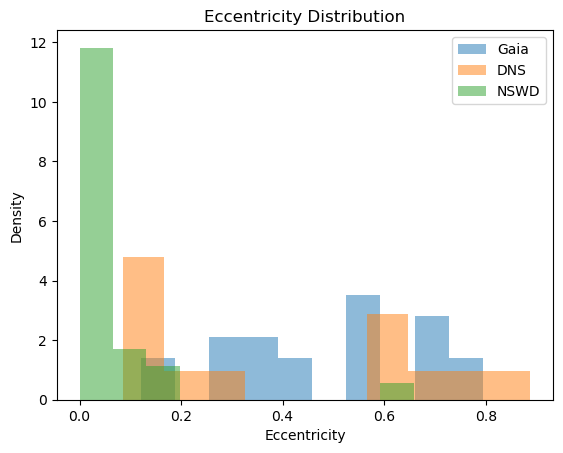

In [191]:
plt.hist(Gaia['ecc'],density=True, bins=10, alpha=0.5, label='Gaia')
plt.hist(DNS['ecc'],density=True, bins=10, alpha=0.5, label='DNS')
plt.hist(NSWD['ecc'],density=True, bins=10, alpha=0.5, label='NSWD')
plt.xlabel('Eccentricity')
plt.ylabel('Density')
plt.title('Eccentricity Distribution')
plt.legend()
plt.show()

# Gaia Mass Distribution Fit

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2038.02it/s, 7 steps of size 6.85e-01. acc. prob=0.82]


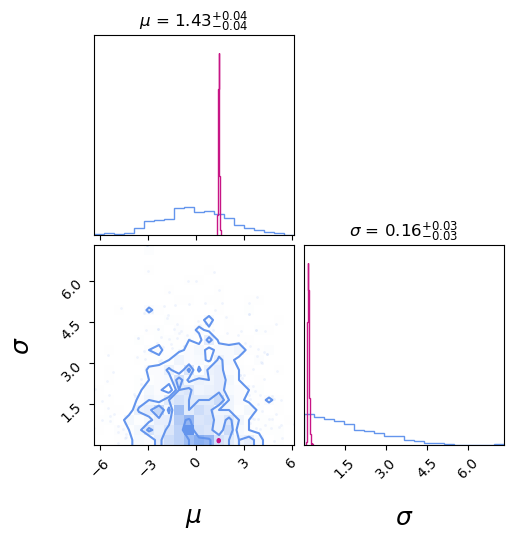

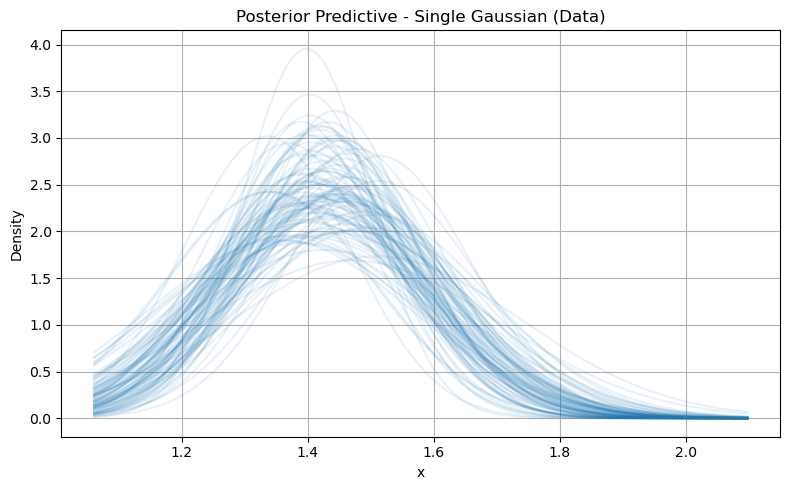

Single Gaussian (Normal Prior):
logl gaussian_normal:  1.4302047





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2222.86it/s, 3 steps of size 9.47e-01. acc. prob=0.86]


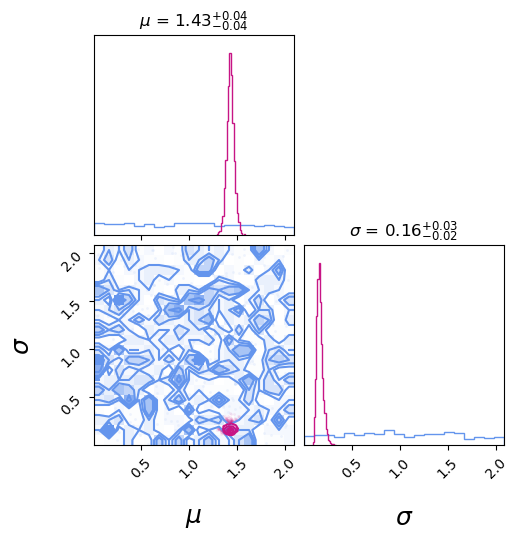

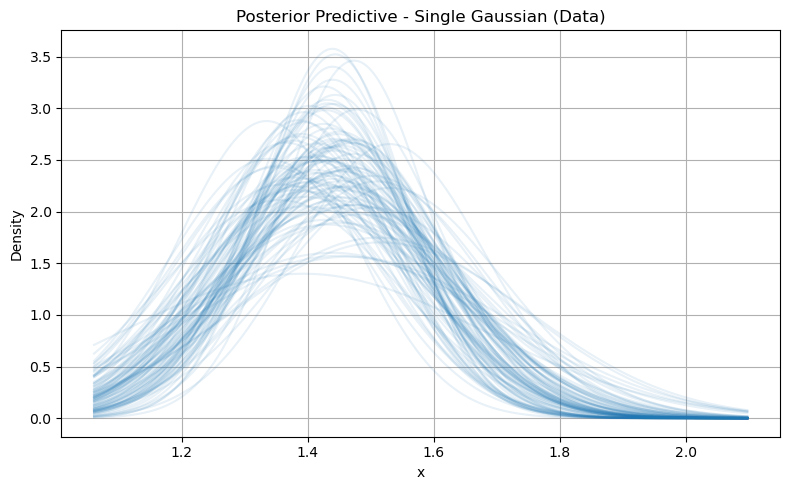

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.4060421





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1479.49it/s, 7 steps of size 3.86e-01. acc. prob=0.92]


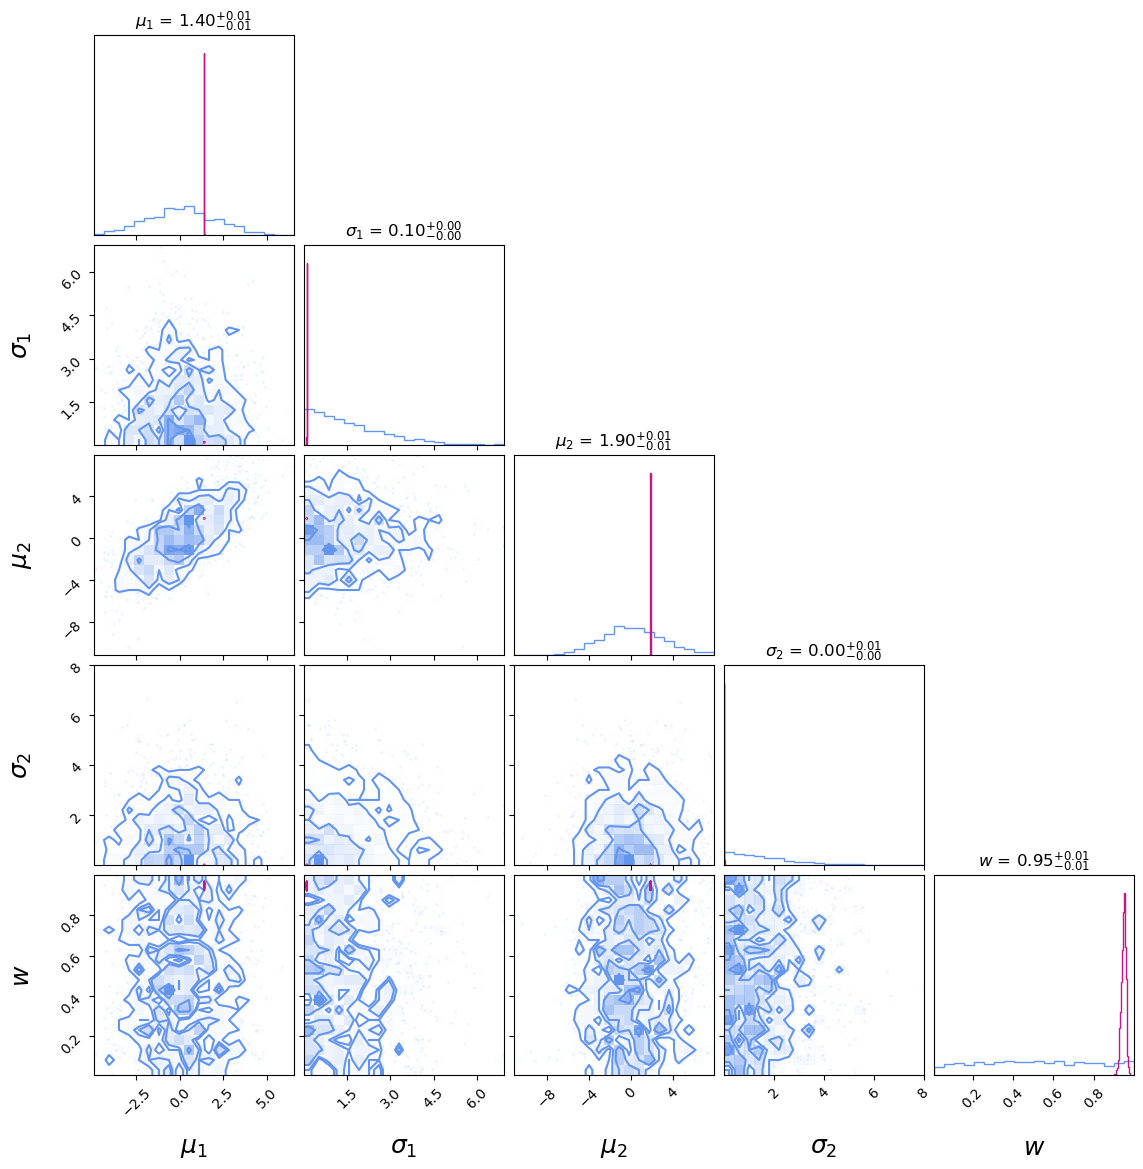

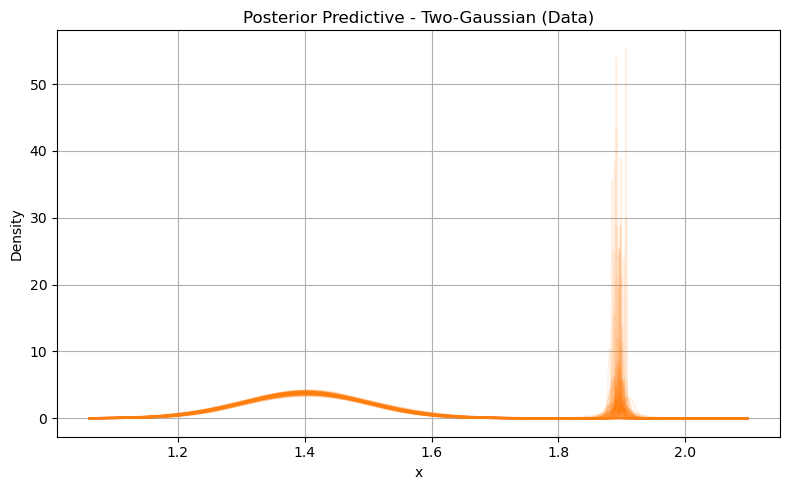

Double Gaussian (Normal Prior):
logl double_normal:  13.541089





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1426.83it/s, 3 steps of size 6.74e-01. acc. prob=0.90]


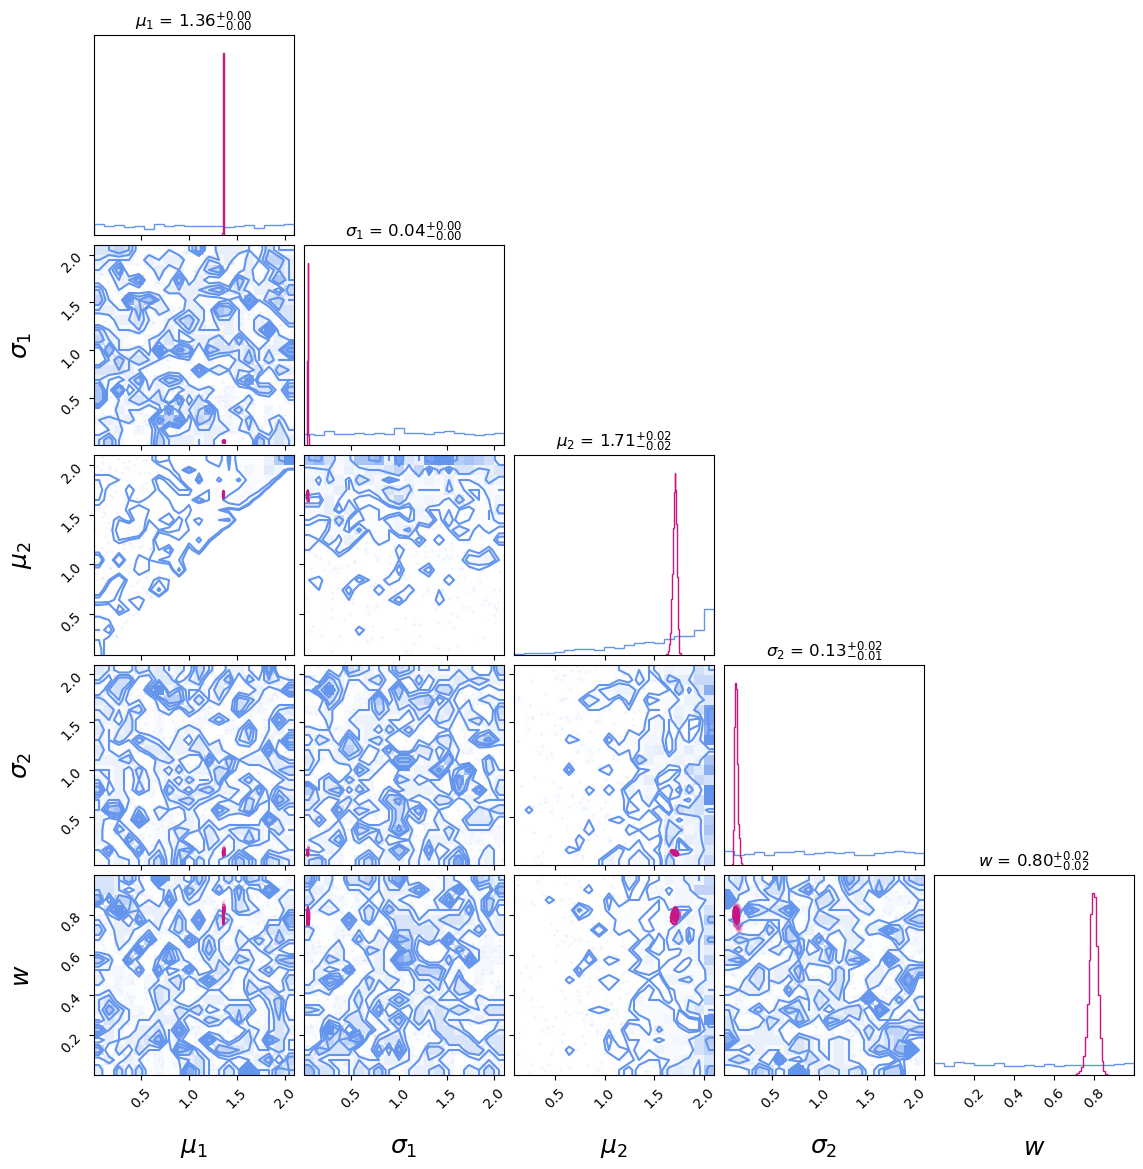

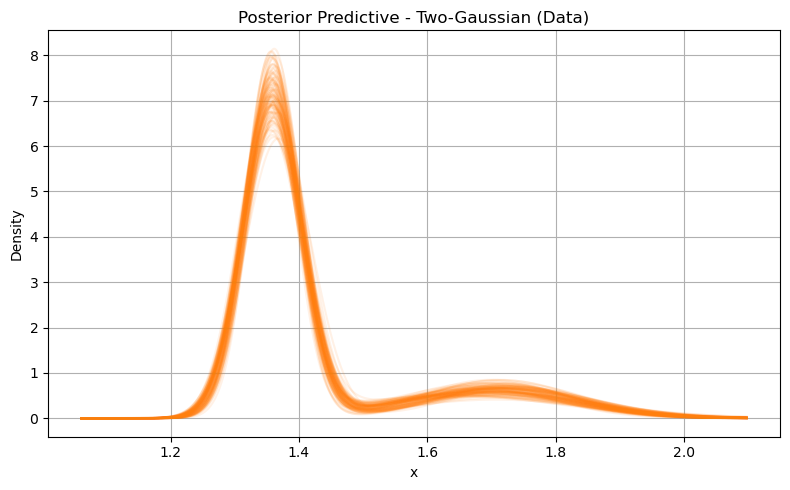

Double Gaussian (Uniform Prior):
logl double_uniform:  17.285828






sample: 100%|██████████| 2000/2000 [00:01<00:00, 1625.60it/s, 7 steps of size 3.06e-01. acc. prob=0.96]


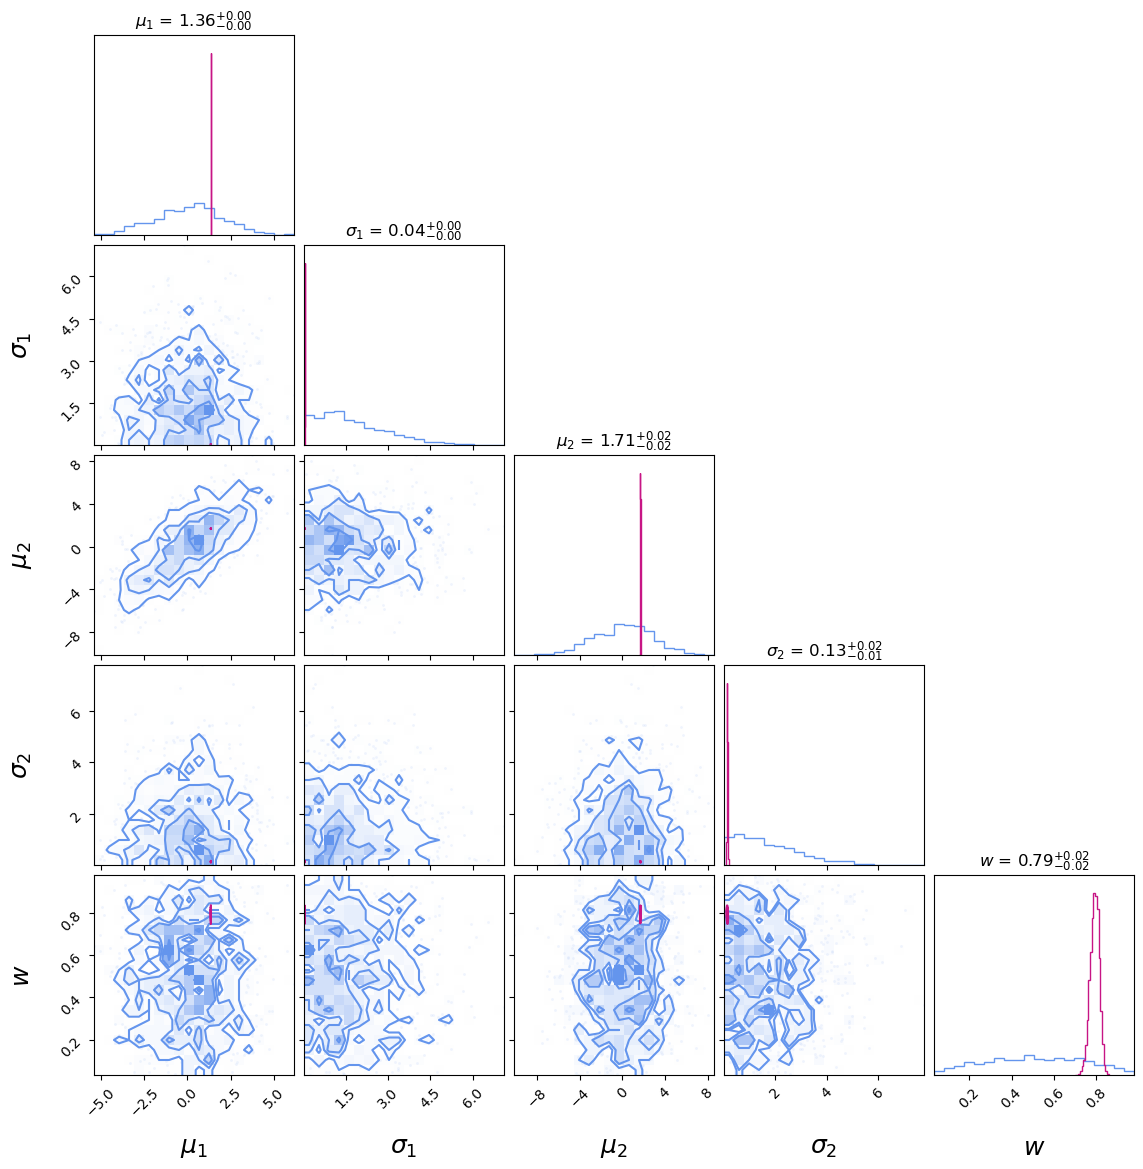

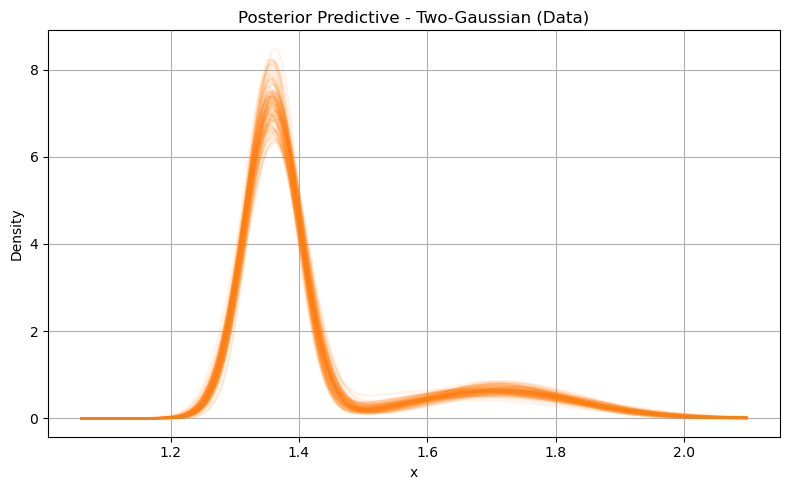

Double Gaussian (Beta Prior):
logl double_beta:  17.287844





In [181]:
data = np.array(Gaia['m1'])  
data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

rng = random.PRNGKey(0)

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

gaia_corner_samples = samples_double_uniform

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - Beta prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)
# 
prior_sampler = MCMC(NUTS(prior_double_gaussian_normal_beta), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))
prior_samples = prior_sampler.get_samples() 

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_double_beta,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_beta, "double", "Posterior: Two-Gaussian Mixture - Beta Prior")
plot_posterior_distributions(mcmc_double_beta, "double", data, label="Data")
print("Double Gaussian (Beta Prior):")
logl_double_beta = log_likelihood(double_gaussian_normal_beta, mcmc_double_beta.get_samples(), data=data, err=data_err)['obs']
print("logl double_beta: ", np.max(logl_double_beta))
print()
print()
print()


# plot_multiple_posterior_distributions(
#     [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
#     ["single", "single", "double", "double", "double", "double"],
#     data,
#     ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
#       "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform))]
#)

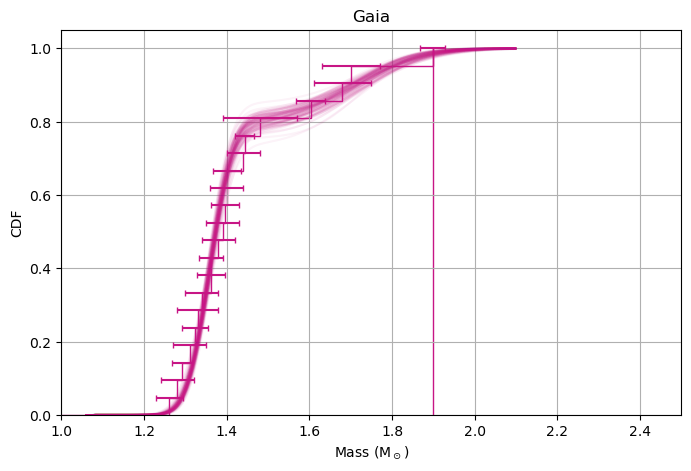

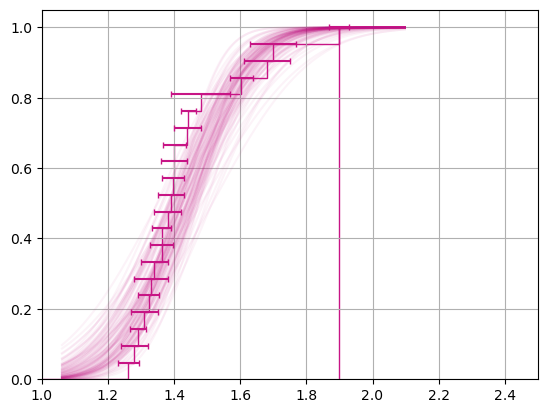

In [182]:
gaiafit = mcmc_double_uniform
gaiafit_single = mcmc_gaussian_uniform

plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
gaiafit_single_samples = gaiafit_single.get_samples()

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins =plot_cdf(gaia_data,gaia_data_err,gaia_data_err)

x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) + (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

for i in np.random.choice(len(gaiafit_single_samples['mu']), 100, replace=False):
    y = scipy.stats.norm.cdf(x, loc=gaiafit_single_samples['mu'][i], scale=gaiafit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

# Recycled NS

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2037.15it/s, 7 steps of size 6.85e-01. acc. prob=0.82]


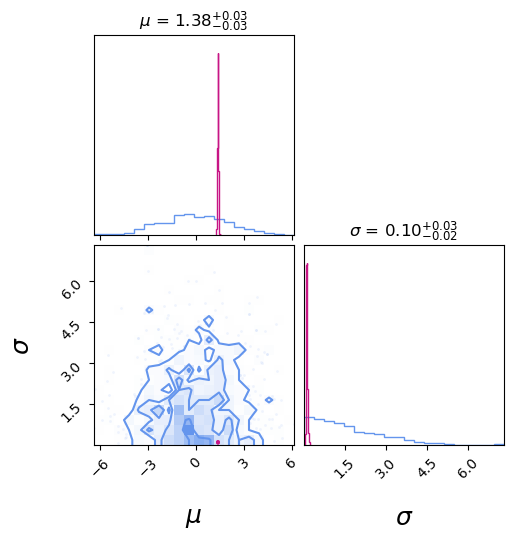

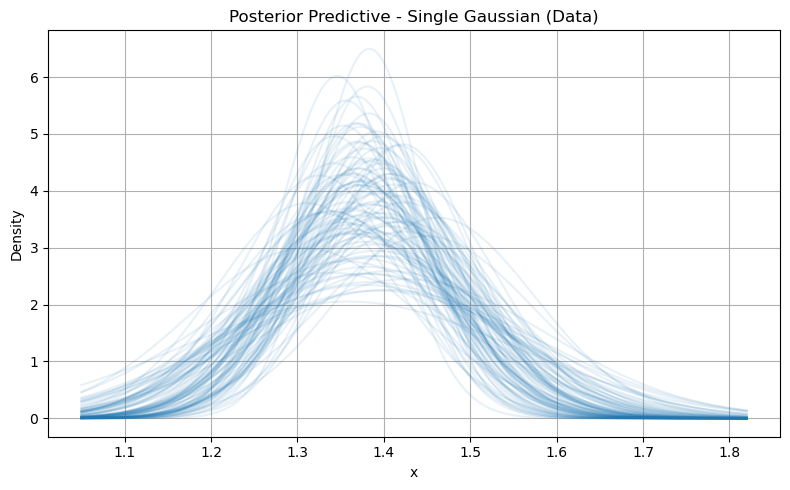

Single Gaussian (Normal Prior):
logl gaussian_normal:  1.9696878





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1978.43it/s, 3 steps of size 9.47e-01. acc. prob=0.86]


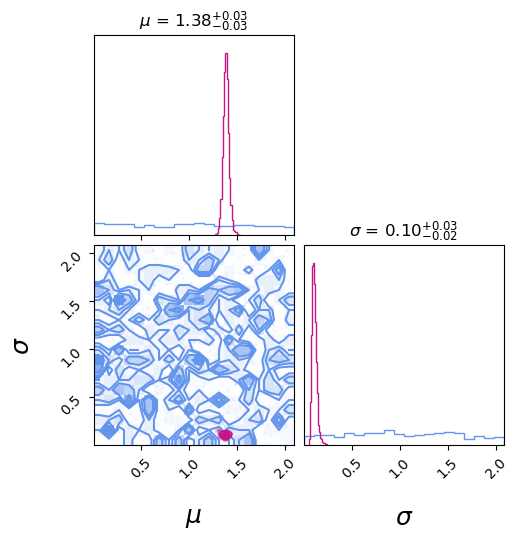

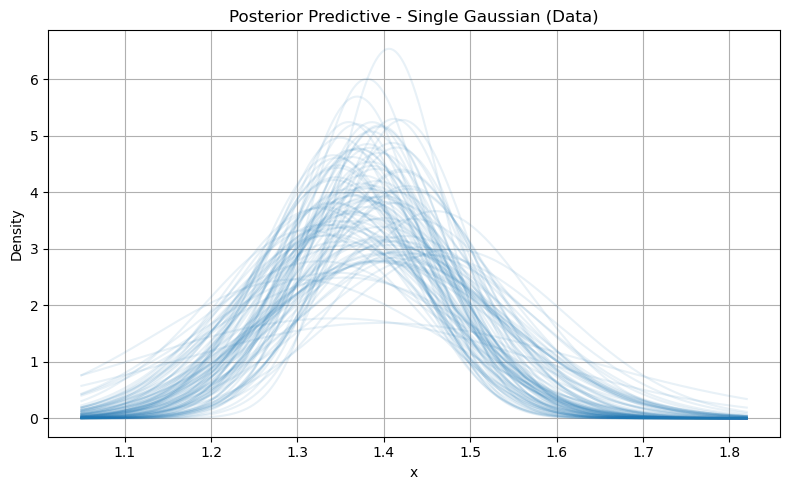

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.9789212





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1688.02it/s, 7 steps of size 3.86e-01. acc. prob=0.92]


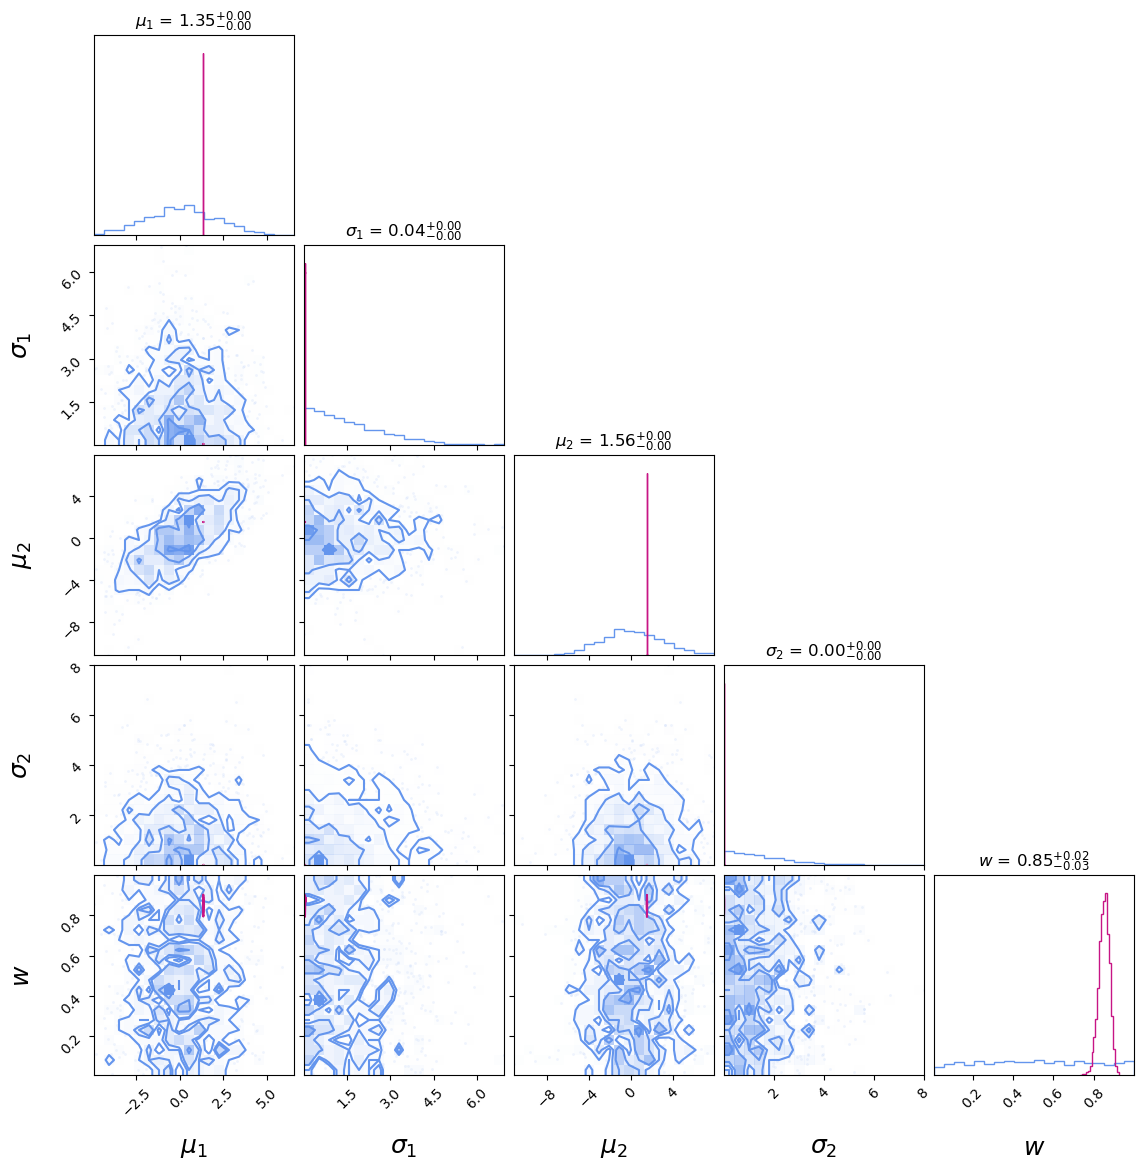

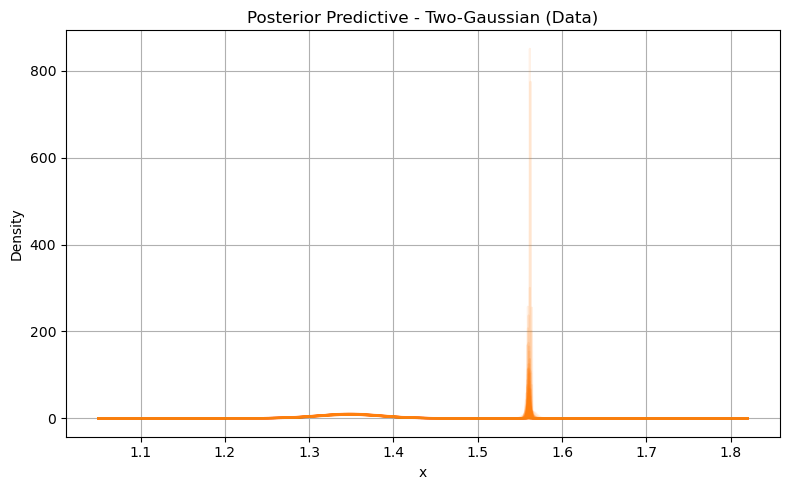

Double Gaussian (Normal Prior):
logl double_normal:  19.850681





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1943.23it/s, 3 steps of size 6.74e-01. acc. prob=0.90]


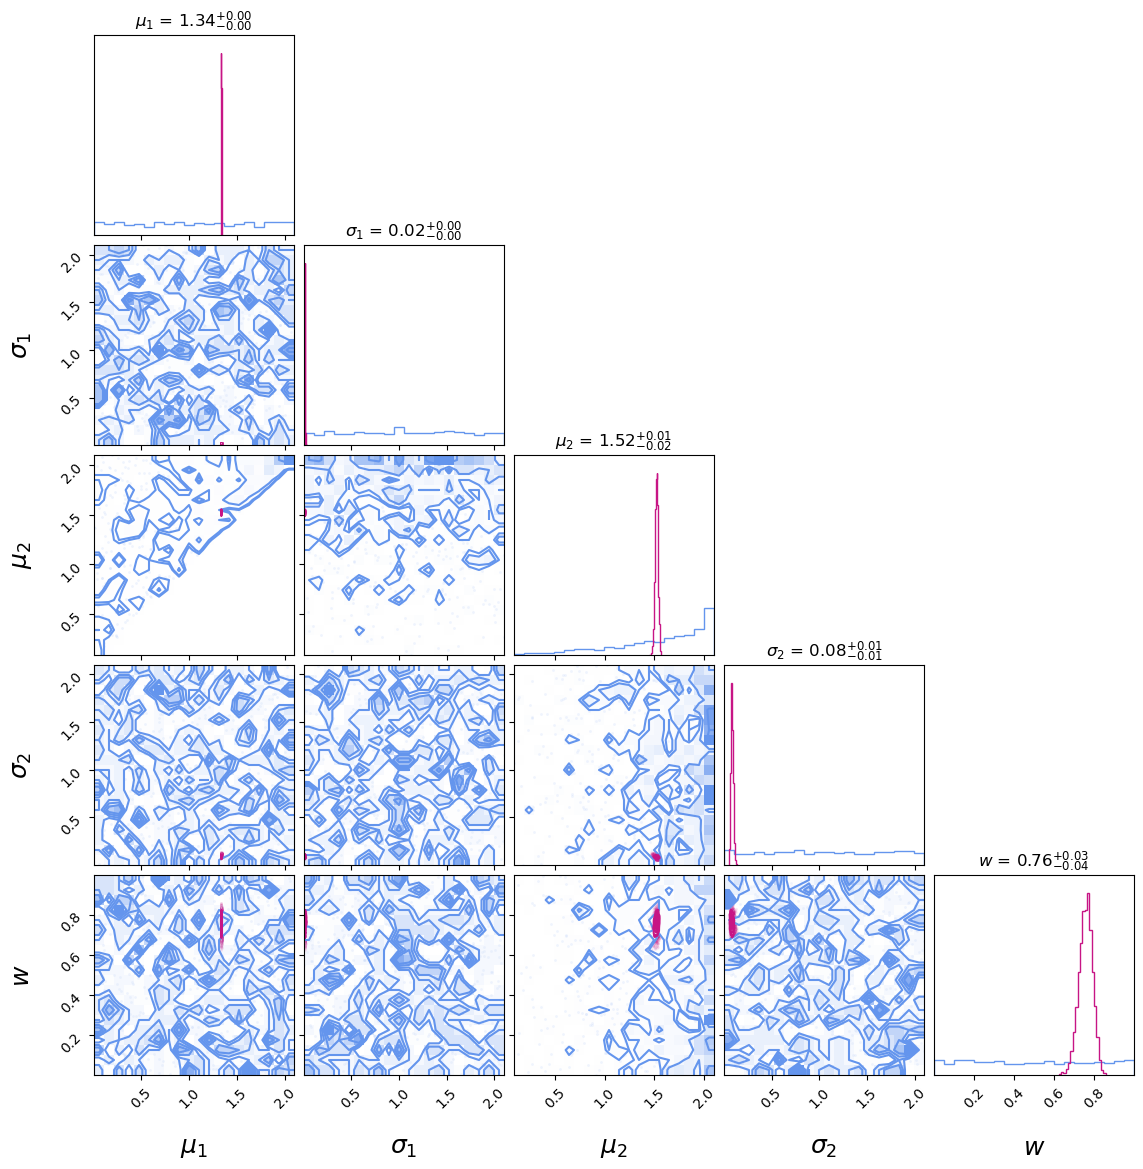

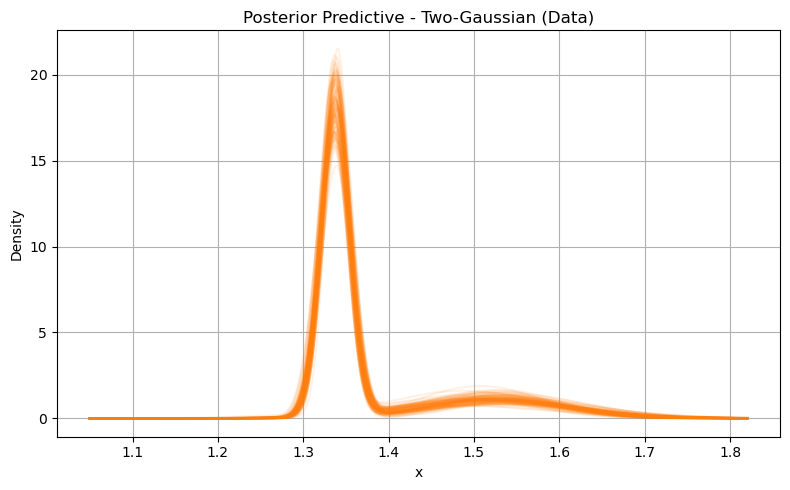

Double Gaussian (Uniform Prior):
logl double_uniform:  21.103535






sample: 100%|██████████| 10000/10000 [00:02<00:00, 4842.18it/s, 7 steps of size 6.74e-01. acc. prob=0.90]


Double Gaussian (Beta Prior):



sample: 100%|██████████| 10000/10000 [00:02<00:00, 4315.15it/s, 7 steps of size 6.17e-01. acc. prob=0.92]

Double Gaussian (Beta Prior):



In [183]:
data = DNS['m1'].dropna().to_numpy()
data_err = DNS[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()


rng = random.PRNGKey(0)

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

DNS_corner_samples = samples_double_uniform

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - beta weight prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)

print("Double Gaussian (Beta Prior):")
print()

# Fit two-component Gaussian - beta uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform_beta = run_inference(double_gaussian_uniform_beta, data, data_err, rng2)
samples_double_uniform_beta = az.from_numpyro(mcmc_double_uniform_beta)
print("Double Gaussian (Beta Prior):")
print()

# plot_multiple_posterior_distributions(
#     [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
#     ["single", "single", "double", "double", "double", "double"],
#     data,
#     ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
#       "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform)), "Double Gaussian (Beta Prior)"+str(np.max(logl_beta_normal)), "Double Gaussian (Uniform Beta Prior)"+str(np.max(logl_beta_uniform))]
#)

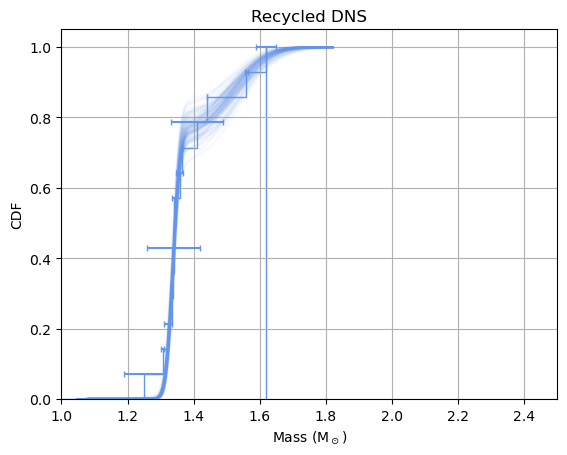

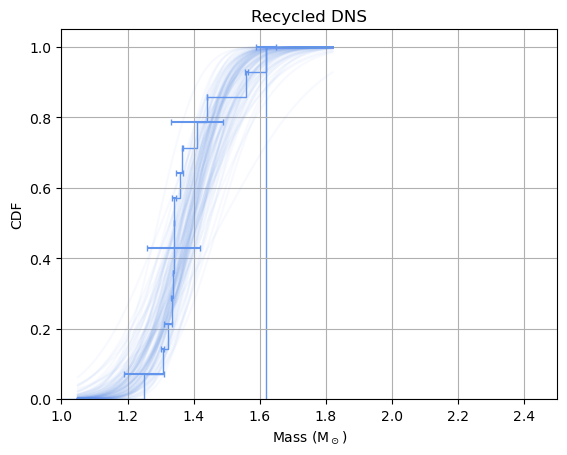

In [184]:
recycledDNSfit = mcmc_double_uniform
recycledDNSfit_samples = recycledDNSfit.get_samples()

recycledDNSfit_single = mcmc_gaussian_uniform
recycledDNSfit_single_samples = recycledDNSfit_single.get_samples()

DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)


x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)


for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]  
    ) + (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

for i in np.random.choice(len(recycledDNSfit_single_samples['mu']), 100, replace=False):
    y =  scipy.stats.norm.cdf(x, loc=recycledDNSfit_single_samples['mu'][i], scale=recycledDNSfit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()




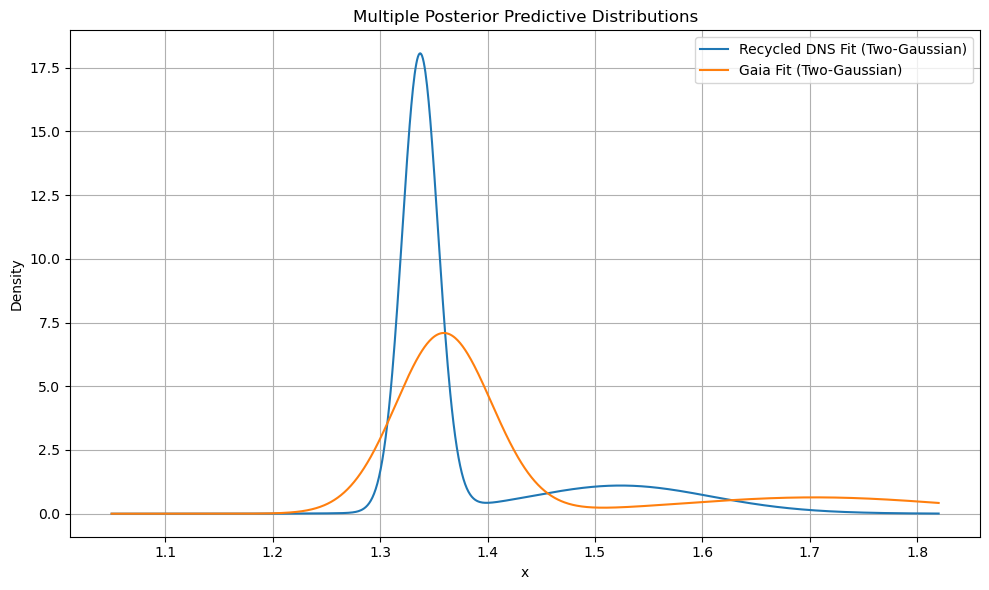

In [185]:
plot_multiple_posterior_distributions([recycledDNSfit, gaiafit], ["double", "double"], data, ["Recycled DNS Fit", "Gaia Fit"])

# Slow Neutron Stars

[1.31   1.354  1.3455 1.27   1.2064 1.3886 1.174  1.299  1.22   1.291
 1.23   1.2489 1.3922 1.46  ]


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2276.19it/s, 7 steps of size 8.22e-01. acc. prob=0.91]


<xarray.Dataset>
Dimensions:         (chain: 1, draw: 5000, true_val_dim_0: 14)
Coordinates:
  * chain           (chain) int64 0
  * draw            (draw) int64 0 1 2 3 4 5 6 ... 4994 4995 4996 4997 4998 4999
  * true_val_dim_0  (true_val_dim_0) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    lower           (chain, draw) float32 1.35 1.255 1.22 ... 1.464 1.487 1.183
    true_val        (chain, draw, true_val_dim_0) float32 1.299 1.365 ... 1.428
    upper           (chain, draw) float32 1.831 1.928 1.933 ... 1.972 1.475
Attributes:
    created_at:                 2025-05-07T02:51:27.494049+00:00
    arviz_version:              0.20.0
    inference_library:          numpyro
    inference_library_version:  0.14.0


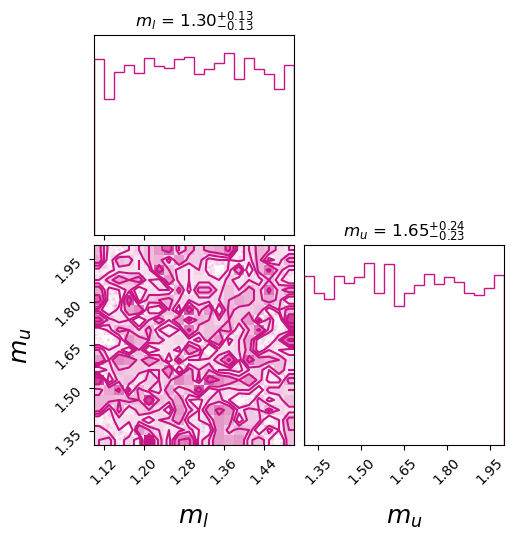

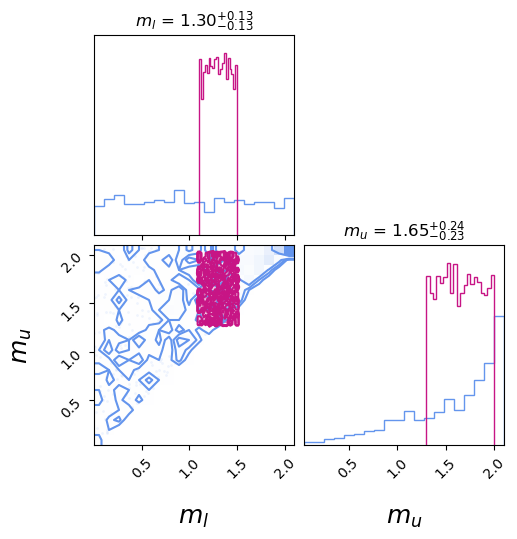

Uniform Distribution:
logl uniform:  7.5982547





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2467.08it/s, 7 steps of size 6.85e-01. acc. prob=0.82]


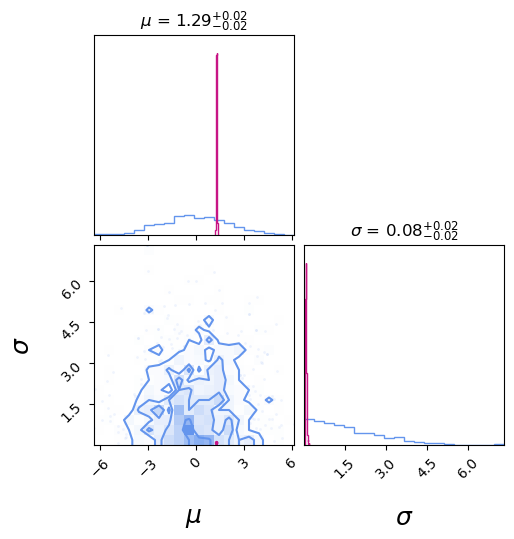

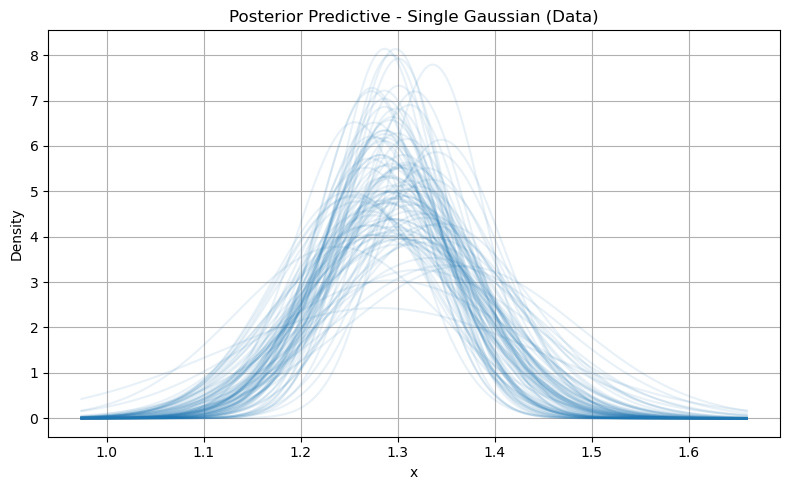

Single Gaussian (Normal Prior):
logl gaussian_normal:  2.2410622





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2328.70it/s, 3 steps of size 9.47e-01. acc. prob=0.86]


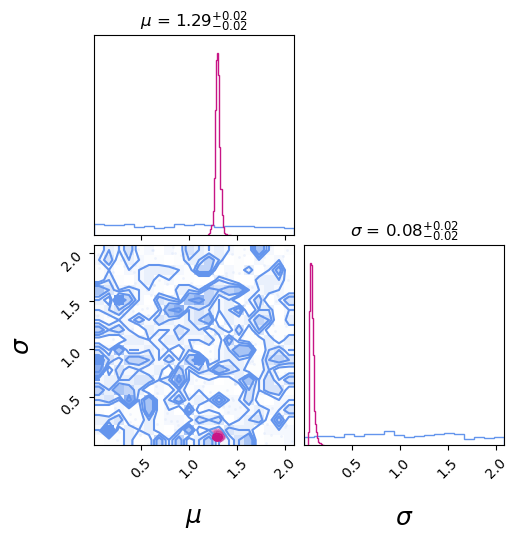

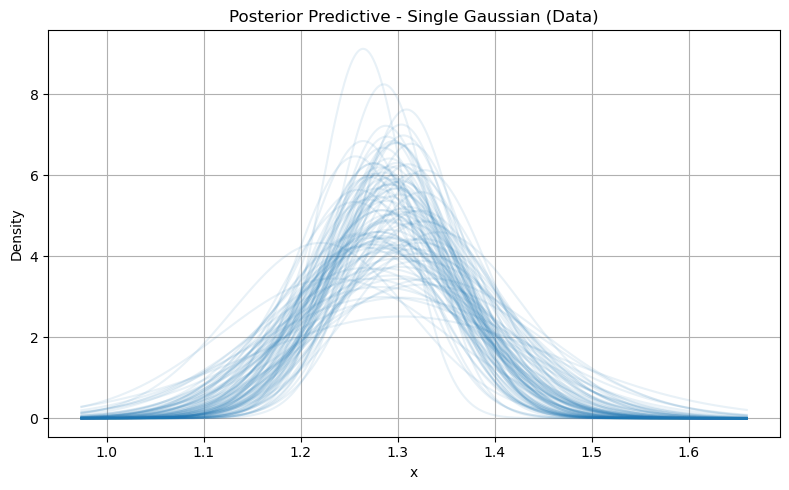

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  2.2516122





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1818.97it/s, 7 steps of size 3.86e-01. acc. prob=0.92]


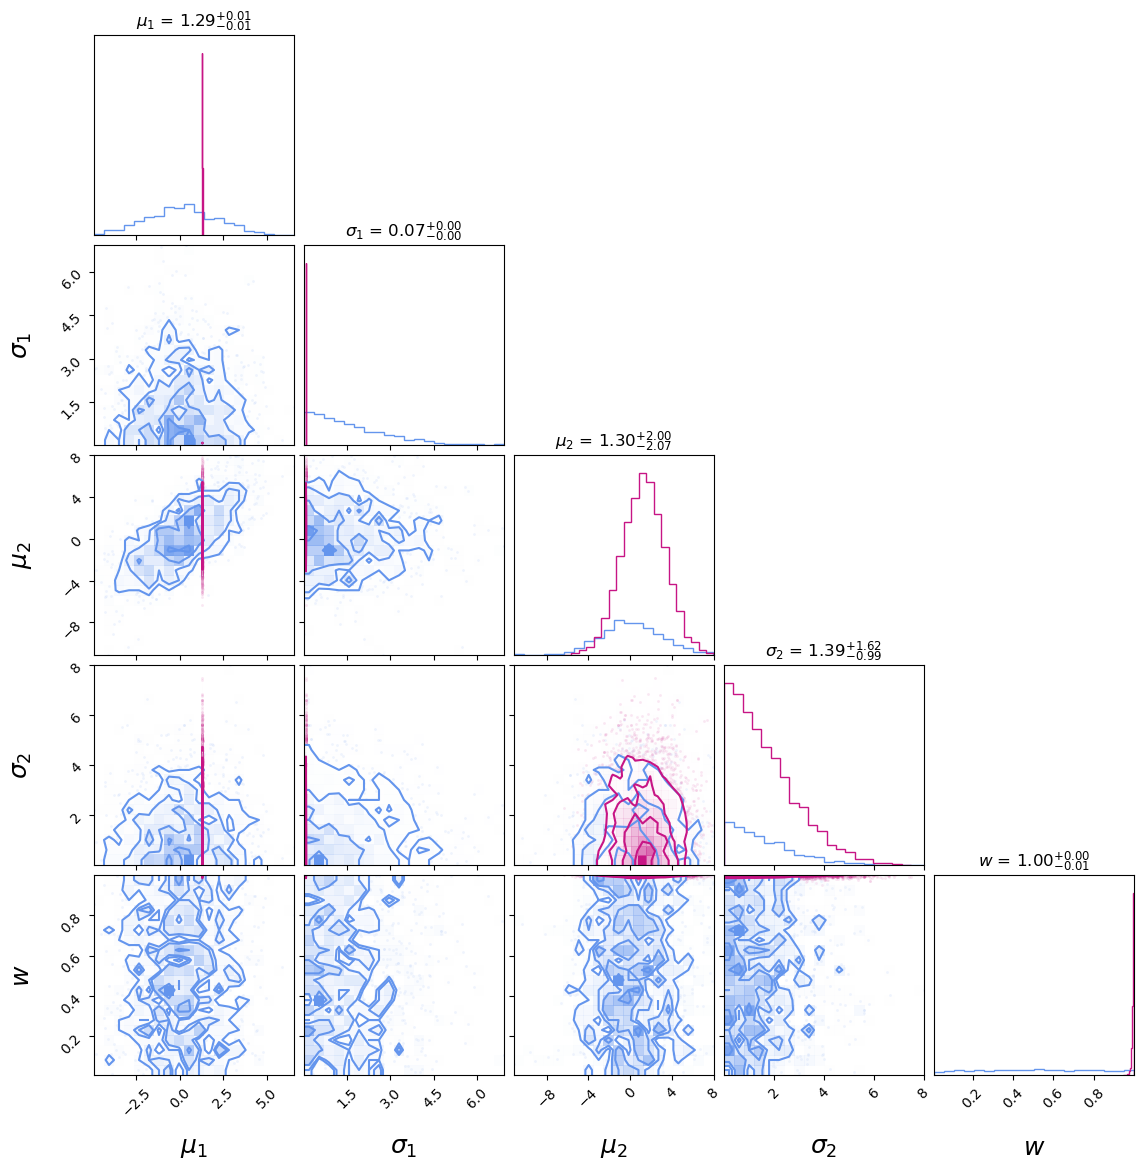

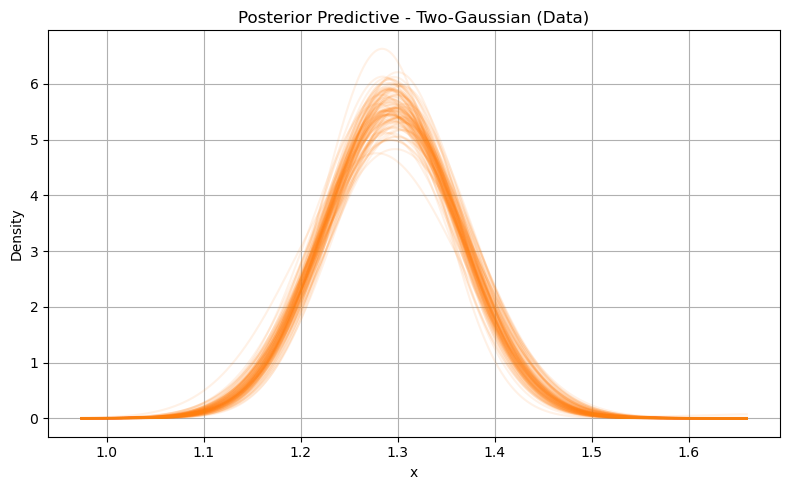

Double Gaussian (Normal Prior):
logl double_normal:  16.135283





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1957.01it/s, 3 steps of size 6.74e-01. acc. prob=0.90]


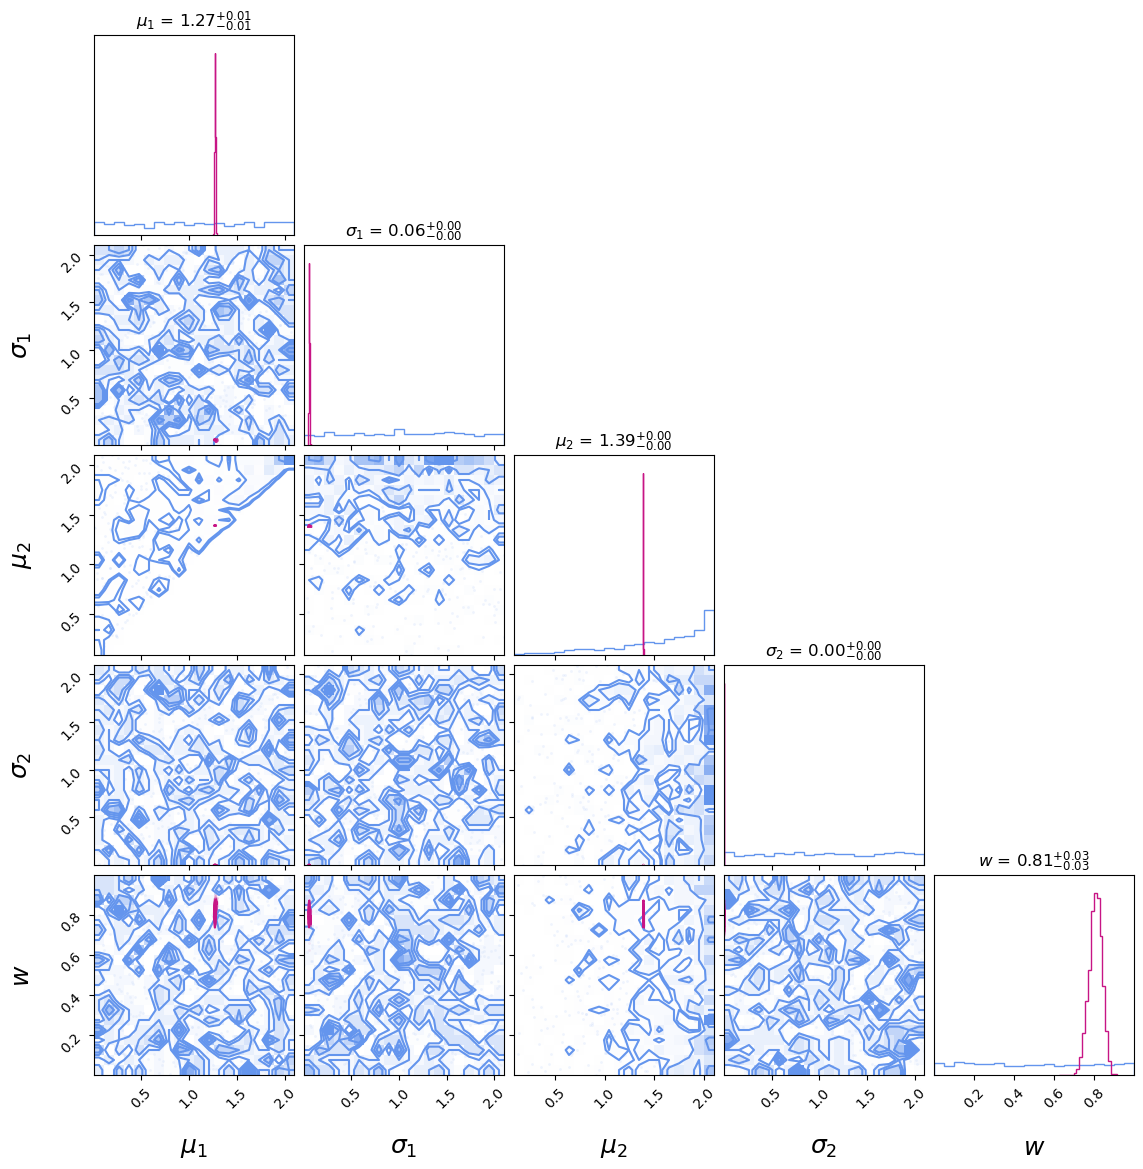

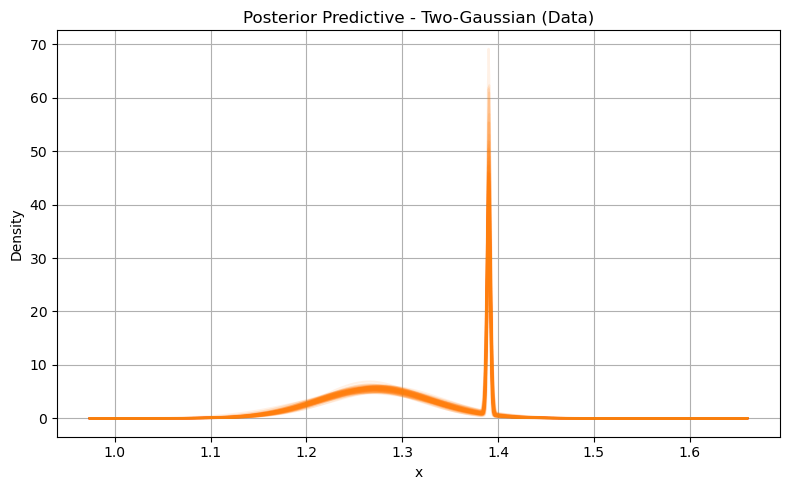

Double Gaussian (Uniform Prior):
logl double_uniform:  20.12339






sample: 100%|██████████| 10000/10000 [00:02<00:00, 3887.09it/s, 15 steps of size 2.61e-01. acc. prob=0.94]


Double Gaussian (Beta Prior):



sample: 100%|██████████| 10000/10000 [00:03<00:00, 3237.30it/s, 63 steps of size 5.30e-02. acc. prob=0.94]


Double Gaussian (Beta Prior):



In [186]:
data = DNS['m2'].dropna().to_numpy()
data_err = DNS[['m2_uerr', 'm2_lerr']].max(axis=1).dropna().to_numpy()

print(data)
rng = random.PRNGKey(0)

#Fit uniform distribution - uniform prior
mcmc_uniform = run_inference(uniform, data, data_err, rng)
samples_uniform = az.from_numpyro(mcmc_uniform)
prior_sampler = MCMC(NUTS(prior_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))
prior_samples = prior_sampler.get_samples()

print(samples_uniform.posterior)

fig = corner.corner(
    samples_uniform,
    var_names=['lower', 'upper'],
    labels=[r"$m_l$", r"$m_u$"],
    color='mediumvioletred',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

fig = corner.corner(
    prior_samples,
    var_names=['lower', 'upper'],
    labels=[r"$m_l$", r"$m_u$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_uniform,
    var_names=['lower', 'upper'],
    labels=[r"$m_l$", r"$m_u$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()


print("Uniform Distribution:")
logl_uniform = log_likelihood(uniform, mcmc_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl uniform: ", np.max(logl_uniform))
print()
print()
print()

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

DNS_corner_samples = samples_double_uniform

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - beta weight prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)

print("Double Gaussian (Beta Prior):")
print()

# Fit two-component Gaussian - beta uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform_beta = run_inference(double_gaussian_uniform_beta, data, data_err, rng2)
samples_double_uniform_beta = az.from_numpyro(mcmc_double_uniform_beta)
print("Double Gaussian (Beta Prior):")
print()

# plot_multiple_posterior_distributions(
#     [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
#     ["single", "single", "double", "double", "double", "double"],
#     data,
#     ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
#       "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform)), "Double Gaussian (Beta Prior)"+str(np.max(logl_beta_normal)), "Double Gaussian (Uniform Beta Prior)"+str(np.max(logl_beta_uniform))]
#)

sample: 100%|██████████| 3000/3000 [00:01<00:00, 1610.92it/s, 1023 steps of size 5.59e-08. acc. prob=0.81]


{'high': Array([1.6441635, 1.6441635, 1.6441635, ..., 1.6441635, 1.6441635,
       1.6441635], dtype=float32), 'low': Array([1.6441631, 1.6441631, 1.6441631, ..., 1.6441631, 1.6441631,
       1.6441631], dtype=float32)}


ValueError: It looks like the parameter(s) in column(s) 0, 1 have no dynamic range. Please provide a `range` argument.

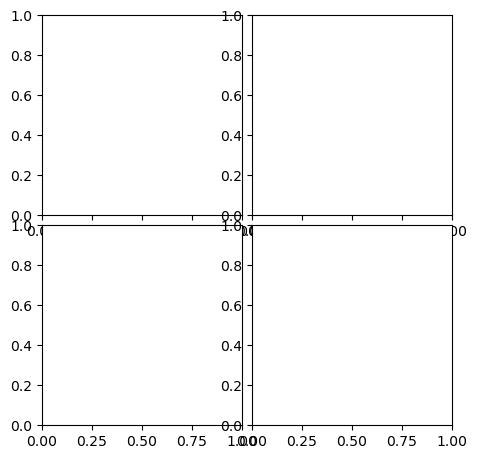

In [187]:
import numpy as np
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import corner

# Your data
data = DNS['m2'].dropna().to_numpy()
data_err = DNS[['m2_uerr', 'm2_lerr']].max(axis=1).dropna().to_numpy()

def fit_uniform(data):

    low = numpyro.sample("low", dist.Uniform(0, 1.8))
    high = numpyro.sample("high", dist.Uniform(1.3, 2.0))

    # Soft constraint: all data should be within [low, high]
    penalty = jnp.where((data >= low) & (data <= high), 0.0, -1e6)
    numpyro.factor("in_bounds", jnp.sum(penalty))

    with numpyro.plate("data", data.shape[0]):
        numpyro.sample("obs", dist.Uniform(low, high), obs=data)


# Run MCMC
rng_key = random.PRNGKey(0)
kernel = NUTS(fit_uniform)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
mcmc.run(rng_key, data=data)
samples = mcmc.get_samples()

print(samples)

# Plot posteriors
corner.corner(samples,var_names=['low', 'high'],
    labels=[r"$m_l$", r"$m_u$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()


sample: 100%|██████████| 3000/3000 [00:02<00:00, 1292.66it/s, 1023 steps of size 7.82e-05. acc. prob=0.98]


{'high': Array([1.5097343, 1.5097342, 1.5097342, ..., 1.5050473, 1.5050675,
       1.5050433], dtype=float32), 'low': Array([1.174    , 1.174    , 1.1739999, ..., 1.160367 , 1.1602949,
       1.1602739], dtype=float32), 'true_val': Array([[1.3459228, 1.2603527, 1.3102227, ..., 1.3375933, 1.4279139,
        1.3529946],
       [1.3459228, 1.2603527, 1.3102226, ..., 1.3375933, 1.4279138,
        1.3529941],
       [1.3459228, 1.2603526, 1.3102225, ..., 1.3375933, 1.4279138,
        1.352994 ],
       ...,
       [1.3370038, 1.2487963, 1.3001724, ..., 1.3207834, 1.41801  ,
        1.343402 ],
       [1.3369836, 1.248741 , 1.3001474, ..., 1.3207467, 1.4180064,
        1.3433641],
       [1.3369458, 1.2487268, 1.3001251, ..., 1.3207119, 1.4179629,
        1.3433325]], dtype=float32)}


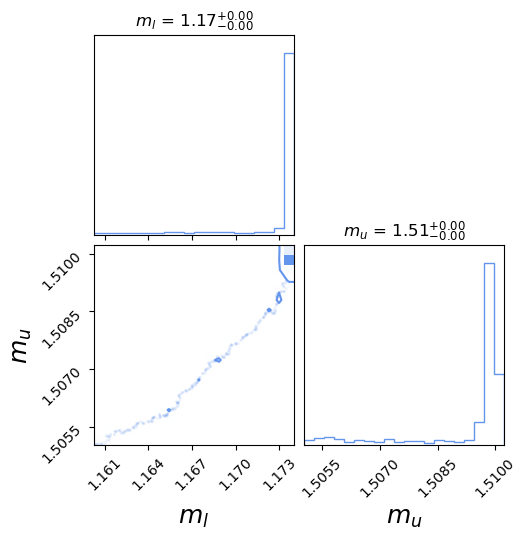

In [ ]:
import numpy as np
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import corner

# Your data
data = DNS['m2'].dropna().to_numpy()
data_err = DNS[['m2_uerr', 'm2_lerr']].max(axis=1).dropna().to_numpy()

def fit_uniform(data,err):

    low = numpyro.sample("low", dist.Uniform(0, 1.8))
    high = numpyro.sample("high", dist.Uniform(1.3, 2.0))

    # Soft constraint: all data should be within [low, high]
    penalty = jnp.where((data >= low) & (data <= high), 0.0, -1e6)
    numpyro.factor("in_bounds", jnp.sum(penalty))

    with numpyro.plate("data", data.shape[0]):
        true_val = numpyro.sample('true_val', dist.Uniform(low, high))
        numpyro.sample('obs', dist.Normal(true_val, err), obs=data)


# Run MCMC
rng_key = random.PRNGKey(0)
kernel = NUTS(fit_uniform)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
mcmc.run(rng_key, data=data, err=data_err)
samples = mcmc.get_samples()

print(samples)
data_to_plot = np.vstack([samples['low'], samples['high']]).T
# Plot posteriors
corner.corner(data_to_plot,#var_names=['low', 'high'],
    labels=[r"$m_l$", r"$m_u$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()


[1.174  1.2064 1.22   1.23   1.2489 1.27   1.291  1.299  1.31   1.354
 1.3886 1.3922 1.46  ] [0.004  0.0021 0.06   0.007  0.0007 0.03   0.011  0.004  0.08   0.01
 0.0002 0.0005 0.08  ]


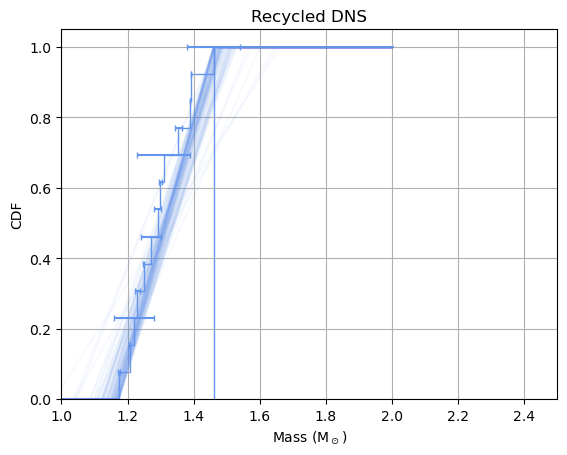

In [ ]:
slowDNSfit = mcmc_uniform
slowDNSfit_samples = samples#slowDNSfit.get_samples()

DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(data,data_err,data_err)

x = np.linspace(1,2, 1000)

for i in np.random.choice(len(slowDNSfit_samples['low']), 100, replace=False):
    y = scipy.stats.uniform.cdf(x, loc=slowDNSfit_samples['low'][i], scale=slowDNSfit_samples['high'][i] - slowDNSfit_samples['low'][i])
    
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Slow DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()





# NS-WD

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2405.03it/s, 7 steps of size 6.85e-01. acc. prob=0.82]


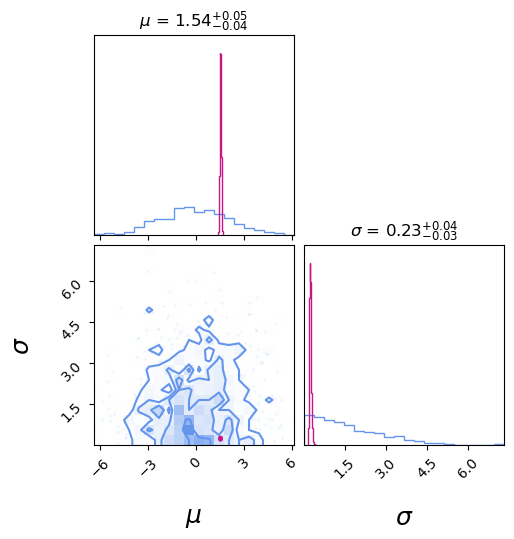

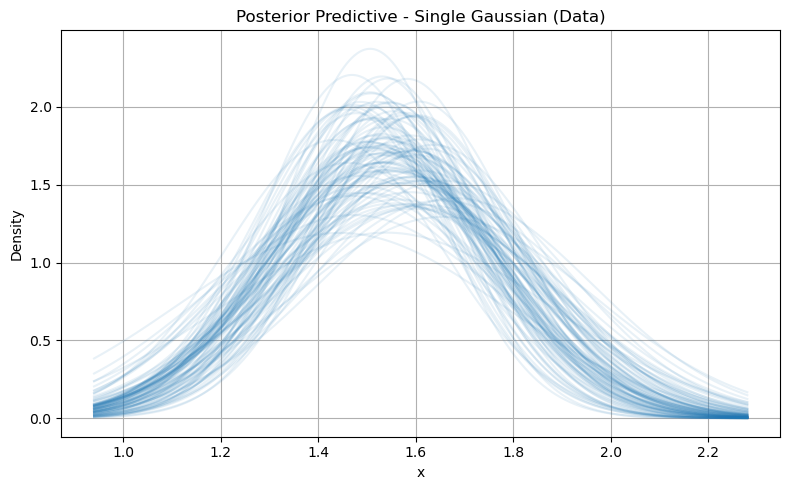

Single Gaussian (Normal Prior):
logl gaussian_normal:  0.9776931





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2227.29it/s, 3 steps of size 9.47e-01. acc. prob=0.86]


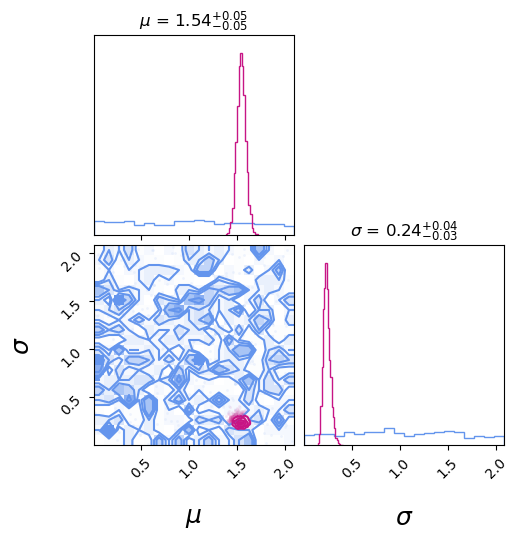

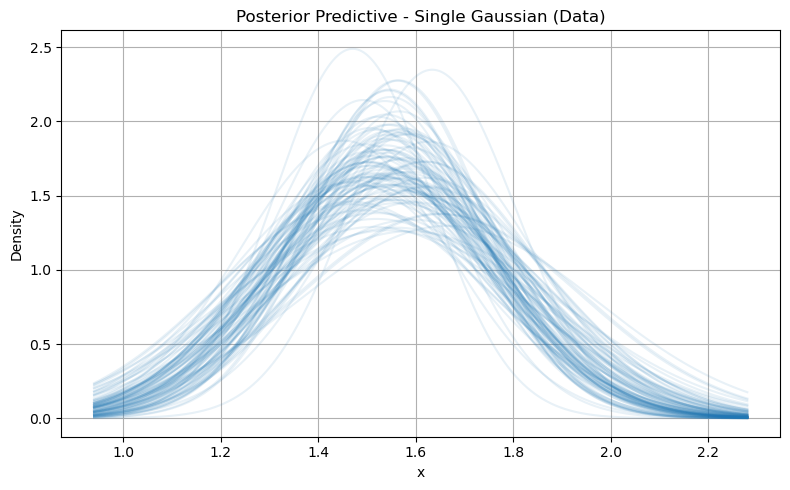

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  0.9204887





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1718.19it/s, 7 steps of size 3.86e-01. acc. prob=0.92]


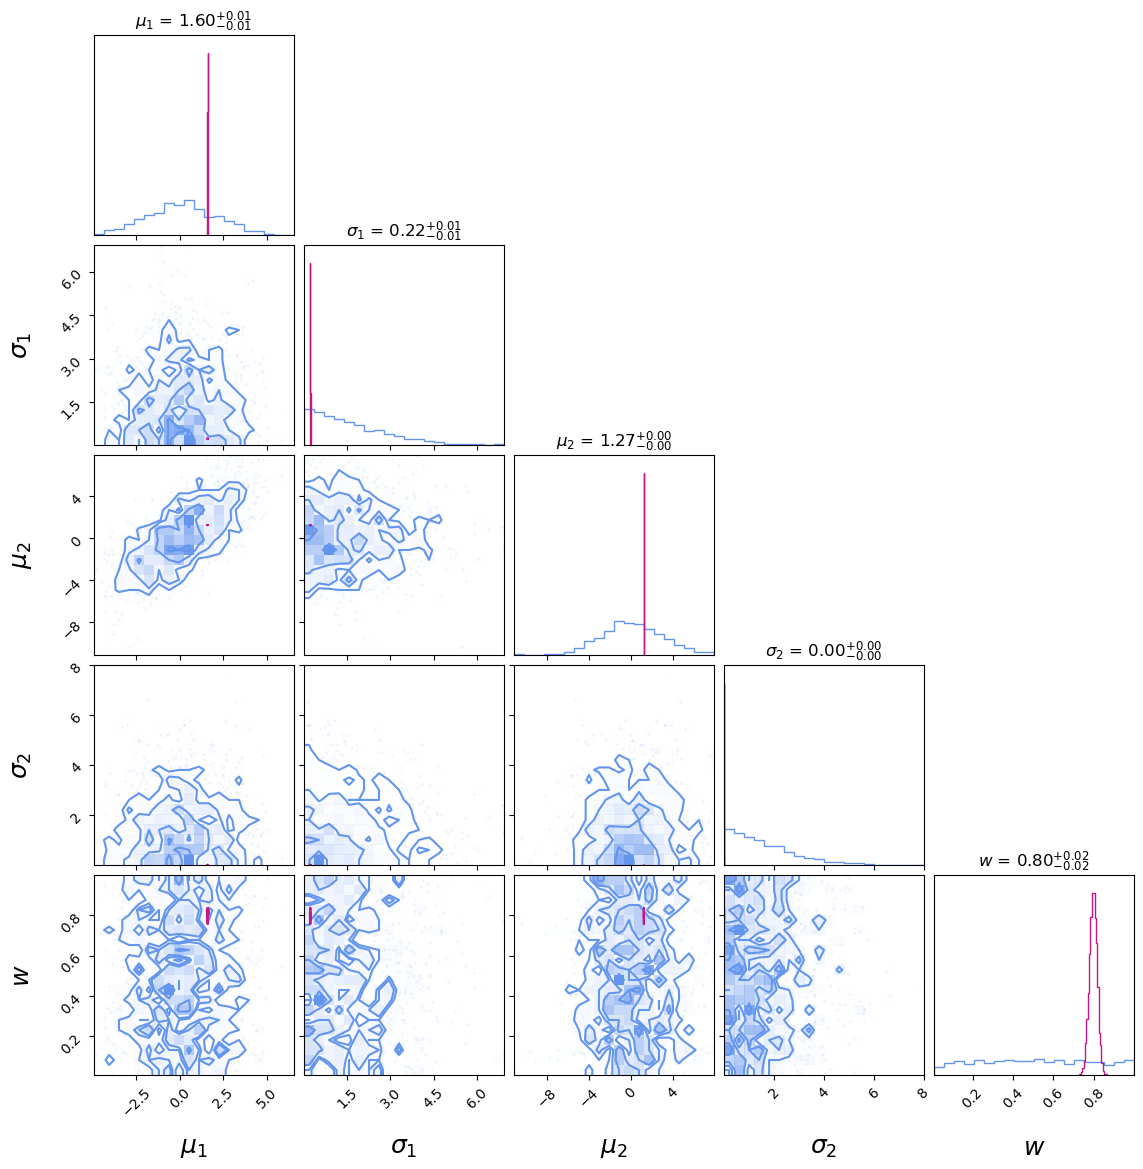

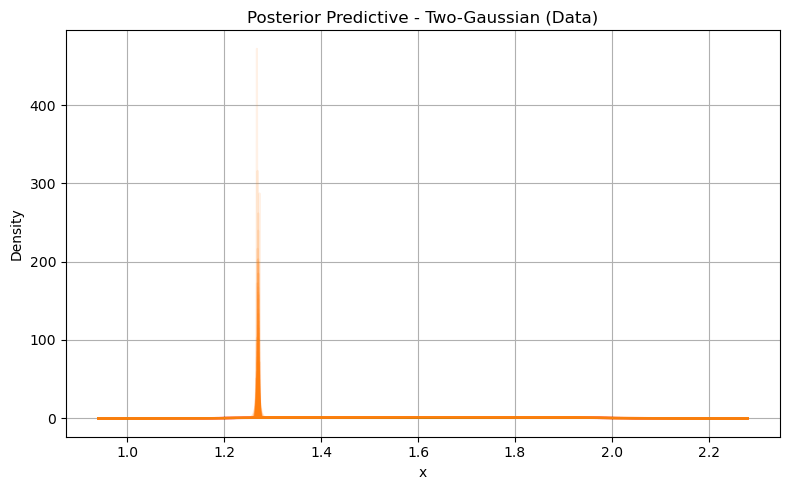

Double Gaussian (Normal Prior):
logl double_normal:  -0.22732413





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1886.65it/s, 3 steps of size 6.74e-01. acc. prob=0.90]


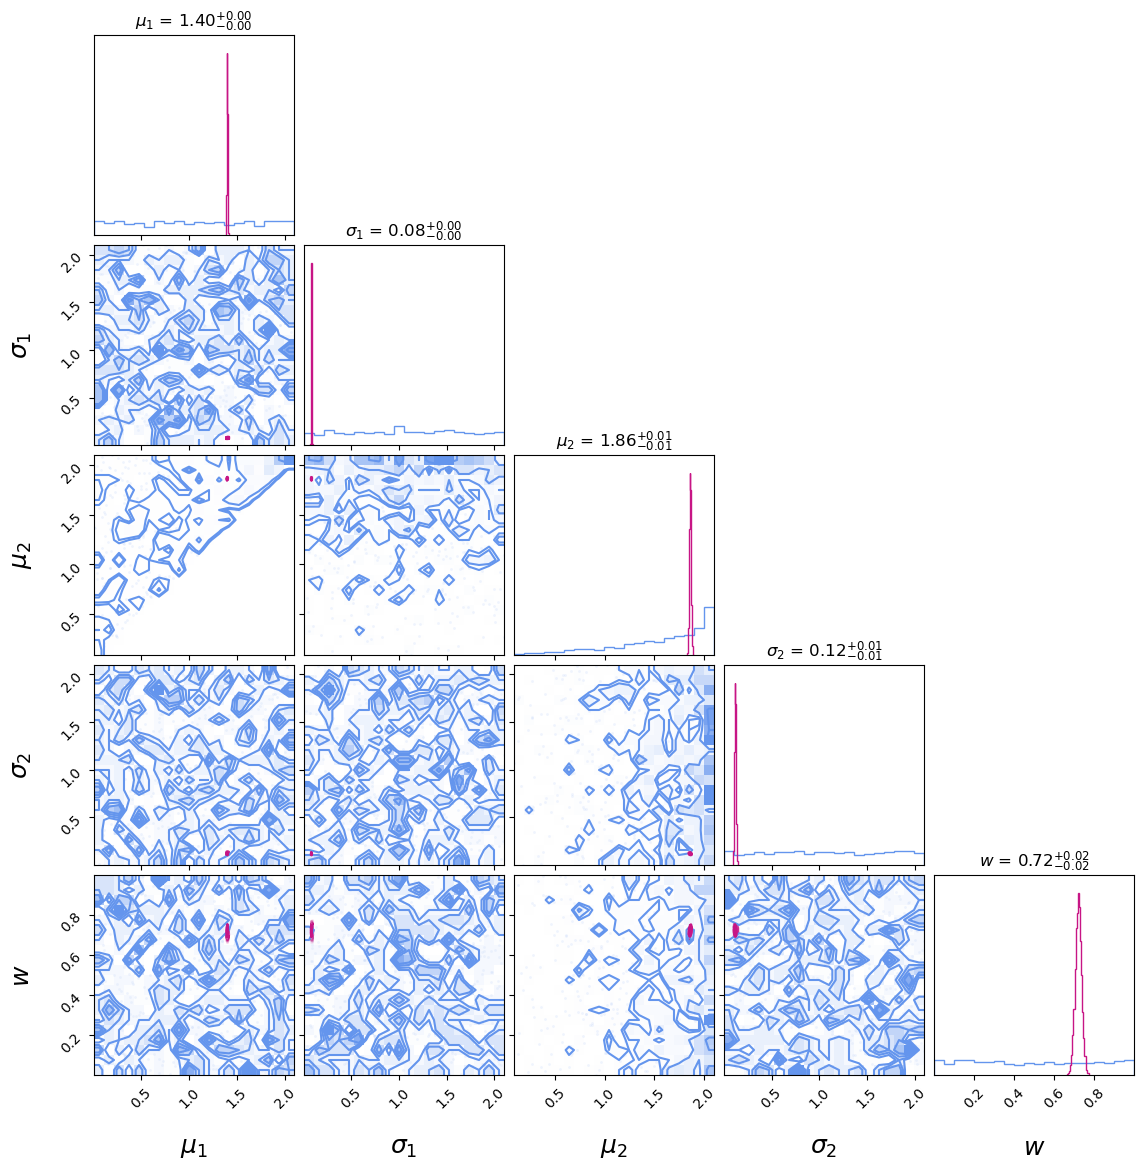

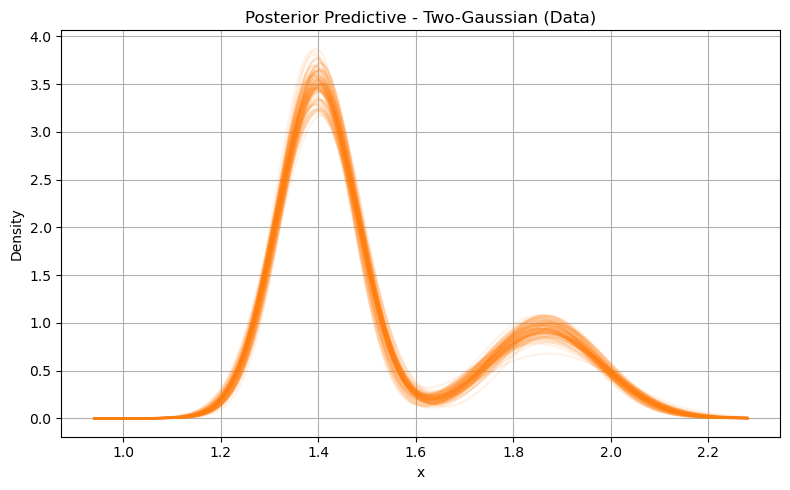

Double Gaussian (Uniform Prior):
logl double_uniform:  3.0845566






sample: 100%|██████████| 10000/10000 [00:02<00:00, 4736.95it/s, 7 steps of size 7.18e-01. acc. prob=0.89]


Double Gaussian (Beta Prior):



sample: 100%|██████████| 10000/10000 [00:02<00:00, 4504.14it/s, 7 steps of size 4.55e-01. acc. prob=0.93]


Double Gaussian (Beta Prior):



In [ ]:
data = NSWD['m1'].dropna().to_numpy()
data_err = NSWD[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()


rng = random.PRNGKey(0)

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

DNS_corner_samples = samples_double_uniform

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - beta weight prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)

print("Double Gaussian (Beta Prior):")
print()

# Fit two-component Gaussian - beta uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform_beta = run_inference(double_gaussian_uniform_beta, data, data_err, rng2)
samples_double_uniform_beta = az.from_numpyro(mcmc_double_uniform_beta)
print("Double Gaussian (Beta Prior):")
print()

# plot_multiple_posterior_distributions(
#     [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
#     ["single", "single", "double", "double", "double", "double"],
#     data,
#     ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
#       "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform)), "Double Gaussian (Beta Prior)"+str(np.max(logl_beta_normal)), "Double Gaussian (Uniform Beta Prior)"+str(np.max(logl_beta_uniform))]
#)

In [ ]:
print(data)

[1.34   1.29   1.72   1.44   1.486  1.908  1.5    1.27   1.61   1.353
 1.831  2.     1.53   1.34   1.4359 1.14   1.44   1.649  1.38   1.251
 1.35   1.38   1.71   1.47   1.4    2.08   1.828  2.01   2.     1.77
 2.08   1.24   1.64   1.33   1.54   1.496  1.37  ]


[1.14   1.24   1.251  1.27   1.29   1.33   1.34   1.34   1.35   1.353
 1.37   1.38   1.38   1.4    1.4359 1.44   1.44   1.47   1.486  1.496
 1.5    1.53   1.54   1.61   1.64   1.649  1.71   1.72   1.77   1.828
 1.831  1.908  2.     2.     2.01   2.08   2.08  ] [4.3e-01 1.1e-01 2.1e-02 1.0e-02 1.0e-01 1.1e-01 1.7e-01 8.0e-02 7.0e-02
 1.7e-02 1.3e-01 1.0e-01 1.3e-01 2.1e-01 3.0e-04 4.4e-01 7.0e-02 7.0e-02
 1.1e-02 2.3e-02 2.0e-01 2.0e-01 1.3e-01 1.4e-01 1.5e-01 1.1e-01 3.0e-02
 1.6e-01 3.6e-01 2.2e-02 1.0e-02 1.6e-02 8.0e-01 8.0e-01 4.0e-02 7.0e-02
 1.9e-01]


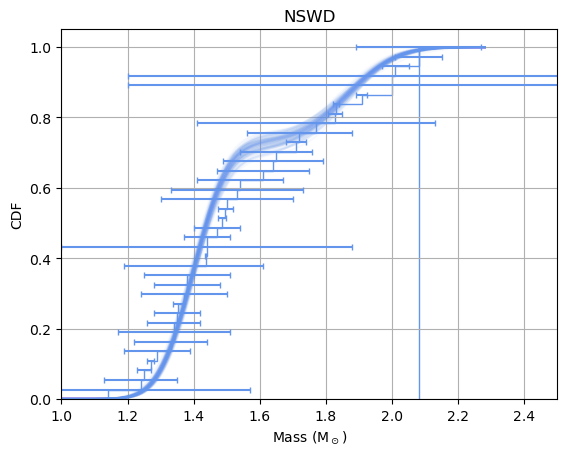

In [ ]:
NSWDfit = mcmc_double_uniform
NSWDfit_samples = NSWDfit.get_samples()


DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(data,data_err,data_err)


x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)
for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
    y = NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]  
    ) + (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')


plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("NSWD")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()


# KS Tests

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_22973/3574687261.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  farrow_posteriors = pd.read_csv('all2_two_uniform.dat', delimiter ='    ', header=None, names=['mu1','mu2', 'sigma1', 'sigma2','weight','ml','mu' ], index_col=False)
/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_22973/3574687261.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  farrow_posteriors = pd.read_csv('all2_two_uniform.dat', delimiter ='    ', header=None, names=['mu1','mu2', 'sigma1', 'sigma2','weight','ml','mu' ], index_col=False)


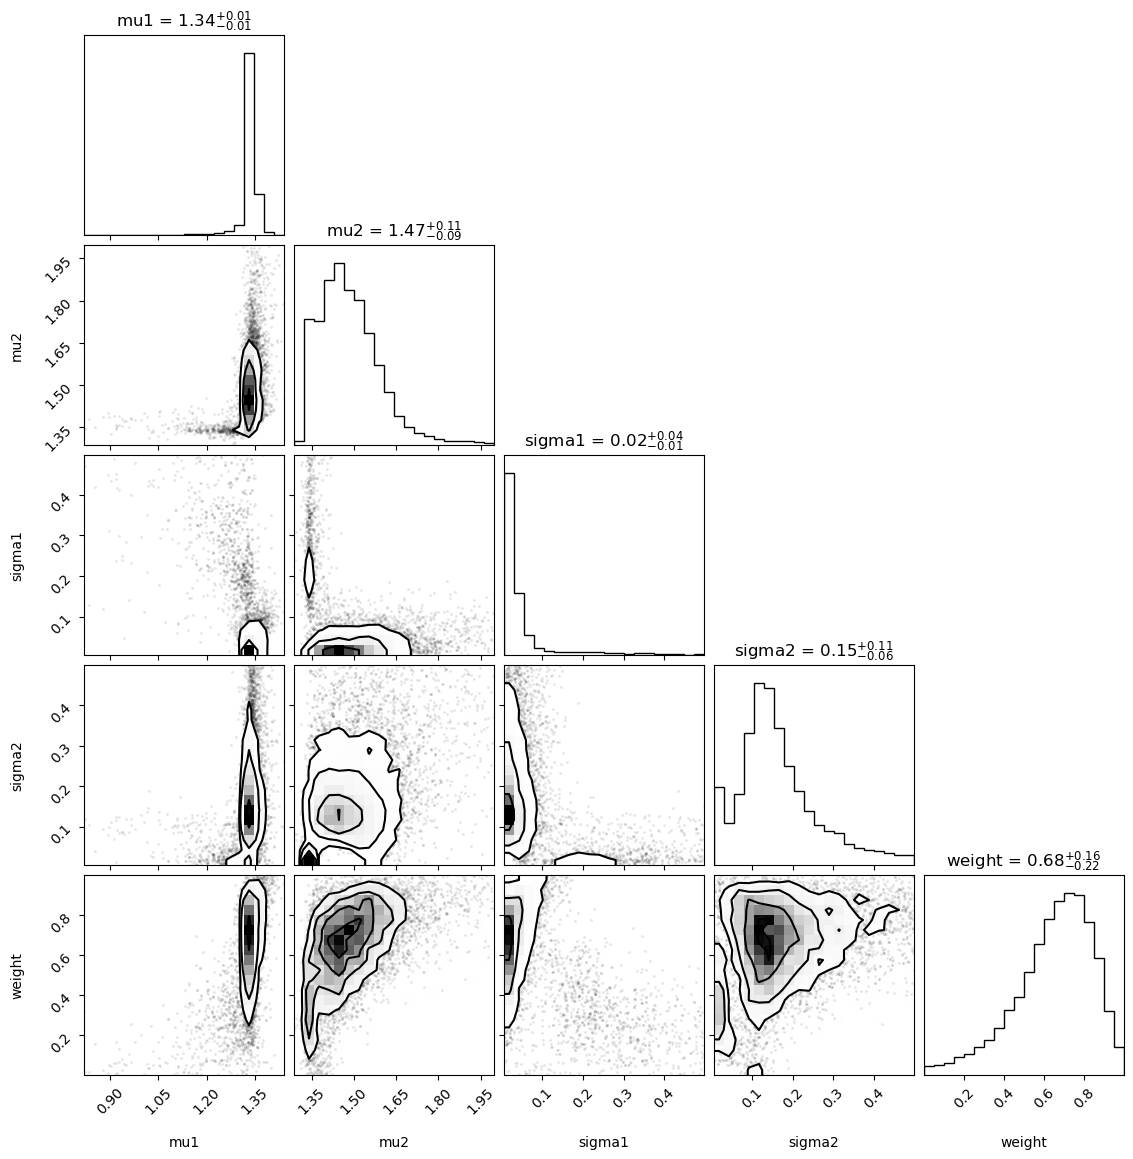

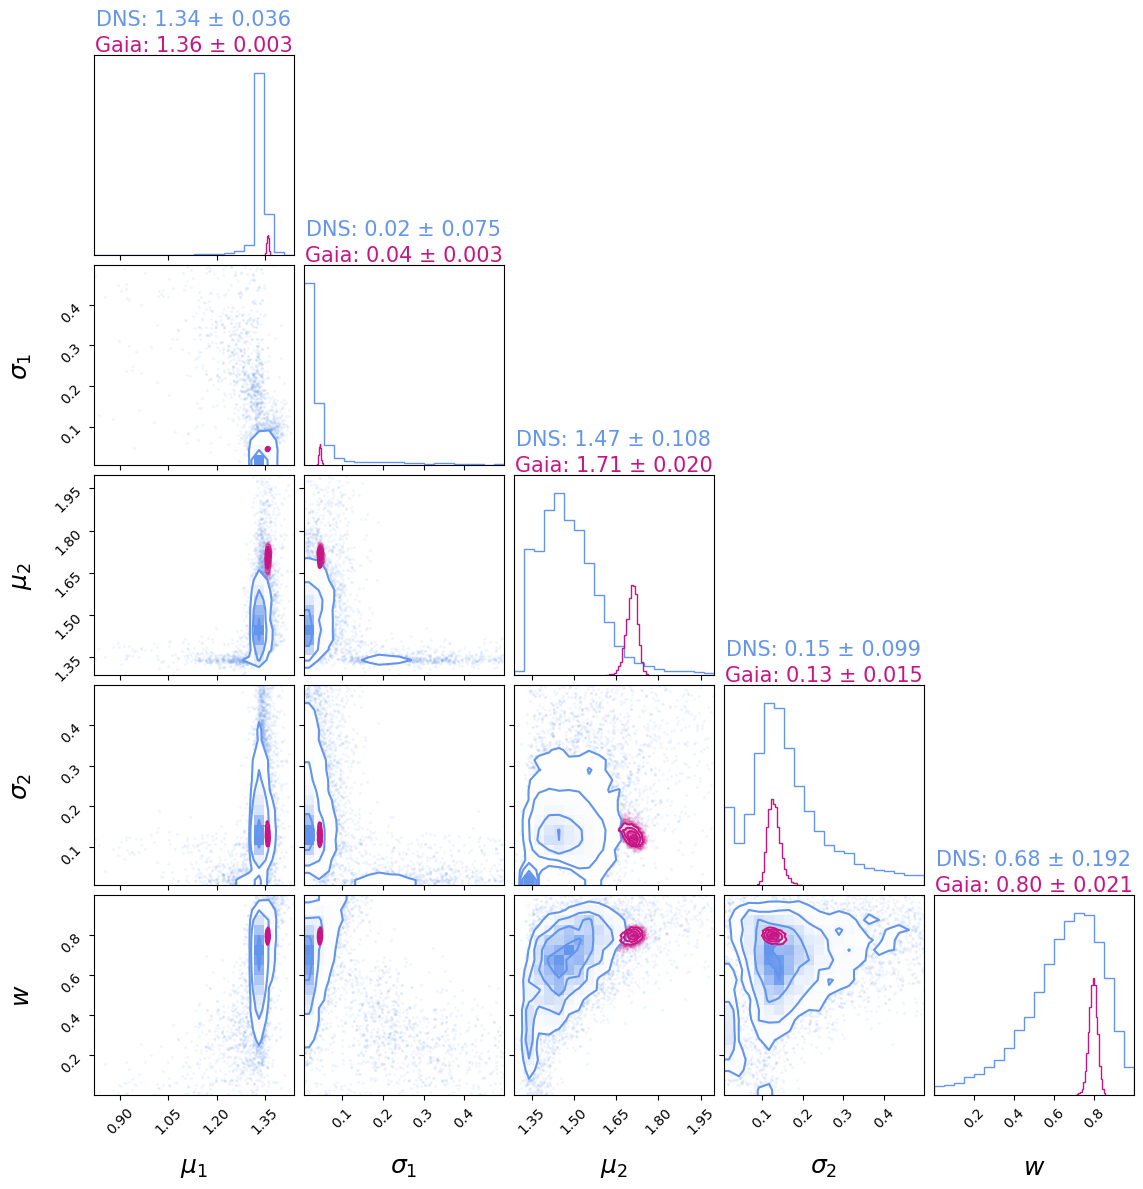

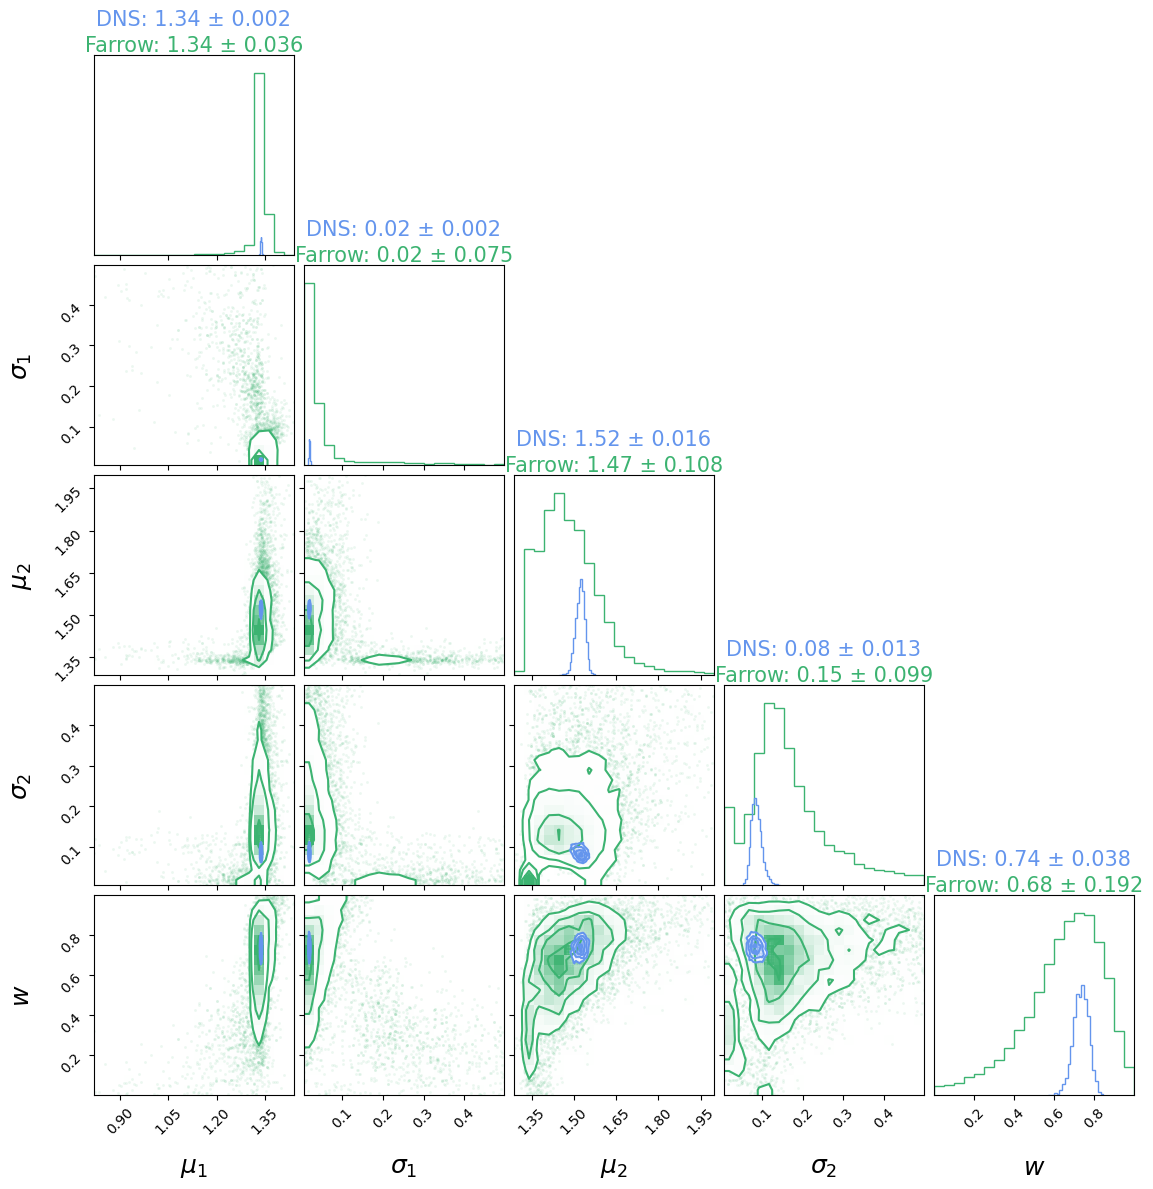

In [ ]:
# farrow posterior
farrow_posteriors = pd.read_csv('all2_two_uniform.dat', delimiter ='    ', header=None, names=['mu1','mu2', 'sigma1', 'sigma2','weight','ml','mu' ], index_col=False)
# Select only the first 5 variables for plotting
columns_to_plot = ['mu1','mu2', 'sigma1', 'sigma2','weight']

# Generate the corner plot for the selected columns
corner.corner(farrow_posteriors[columns_to_plot], show_titles=True)
plt.show()


# Variables
params = ['mu1', 'sigma1', 'mu2', 'sigma2', 'weight']
labels = [r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"]

# Step 1: Plot both datasets without titles
fig = corner.corner(
    farrow_posteriors,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    gaia_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumvioletred',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

# Step 2: Add your own titles manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_dns = np.median(farrow_posteriors[param])
    std_dns = np.std(farrow_posteriors[param])
    median_gaia = np.median(gaia_corner_samples.posterior[param])
    std_gaia = np.std(gaia_corner_samples.posterior[param])

    # Add DNS title (top line)
    ax.text(0.5, 1.13,
            f"DNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)

    # Add Gaia title (second line just below)
    ax.text(0.5, 1.00,
            f"Gaia: {median_gaia:.2f} ± {std_gaia:.3f}",
            fontsize=15, color='mediumvioletred',
            ha='center', va='bottom', transform=ax.transAxes)
plt.show()

# Step 1: Plot both datasets without titles
fig = corner.corner(
    farrow_posteriors,
    var_names=params,
    labels=labels,
    color='mediumseagreen',
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    DNS_corner_samples,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)
# Step 2: Add your own titles manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_farrow = np.median(farrow_posteriors[param])
    std_farrow = np.std(farrow_posteriors[param])
    # Compute summary stats
    median_dns = np.median(DNS_corner_samples.posterior[param])
    std_dns = np.std(DNS_corner_samples.posterior[param])

    # Add DNS title (top line)
    ax.text(0.5, 1.13,
            f"DNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)
    # Add DNS title (top line)
    ax.text(0.5, 1.00,
            f"Farrow: {median_farrow:.2f} ± {std_farrow:.3f}",
            fontsize=15, color='mediumseagreen',
            ha='center', va='bottom', transform=ax.transAxes)

plt.show()

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_22973/4250978137.py:25: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


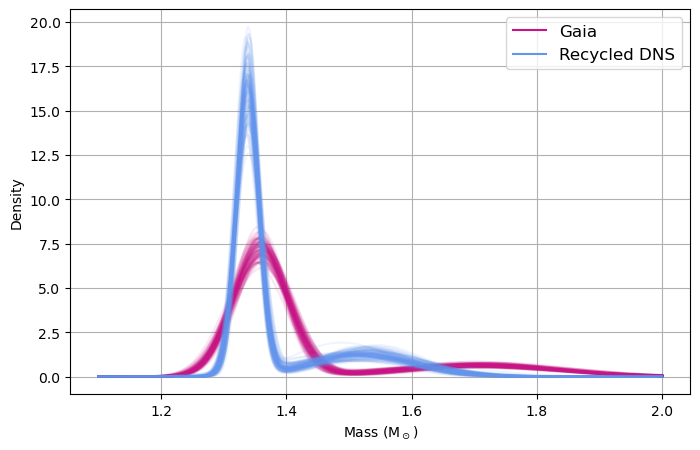

[1.261 1.28  1.291 1.31  1.323 1.33  1.34  1.362 1.362 1.38  1.39  1.396
 1.4   1.401 1.44  1.443 1.48  1.603 1.68  1.7   1.898] [0.032 0.04  0.024 0.04  0.032 0.05  0.04  0.034 0.03  0.04  0.04  0.033
 0.04  0.034 0.04  0.023 0.09  0.035 0.07  0.07  0.03 ]
[1.25   1.306  1.322  1.3381 1.34   1.3406 1.341  1.358  1.3655 1.41
 1.4398 1.559  1.62  ] [0.06   0.004  0.011  0.0007 0.08   0.0005 0.007  0.01   0.0021 0.08
 0.0002 0.005  0.03  ]


/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_22973/4250978137.py:60: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


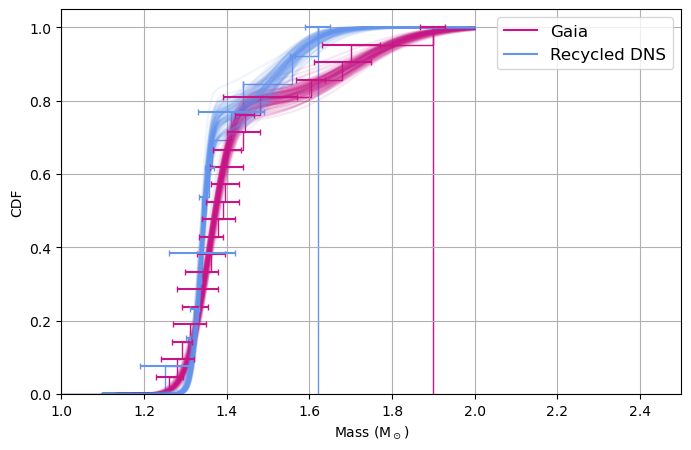

In [ ]:
plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
recycledDNSfit_samples = recycledDNSfit.get_samples()
x = np.linspace(1.1, 2, 1000)

plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1

plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1

plt.grid()
plt.ylabel("Density")
plt.xlabel("Mass (M$_\odot$)")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  # Make the legend handles fully opaque
plt.show()

plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
recycledDNSfit_samples = recycledDNSfit.get_samples()

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins =plot_cdf(gaia_data,gaia_data_err,gaia_data_err)
DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)


plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1
plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1
plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.xlim(1.0, 2.5)
plt.grid()
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  # Make the legend handles fully opaque
plt.show()




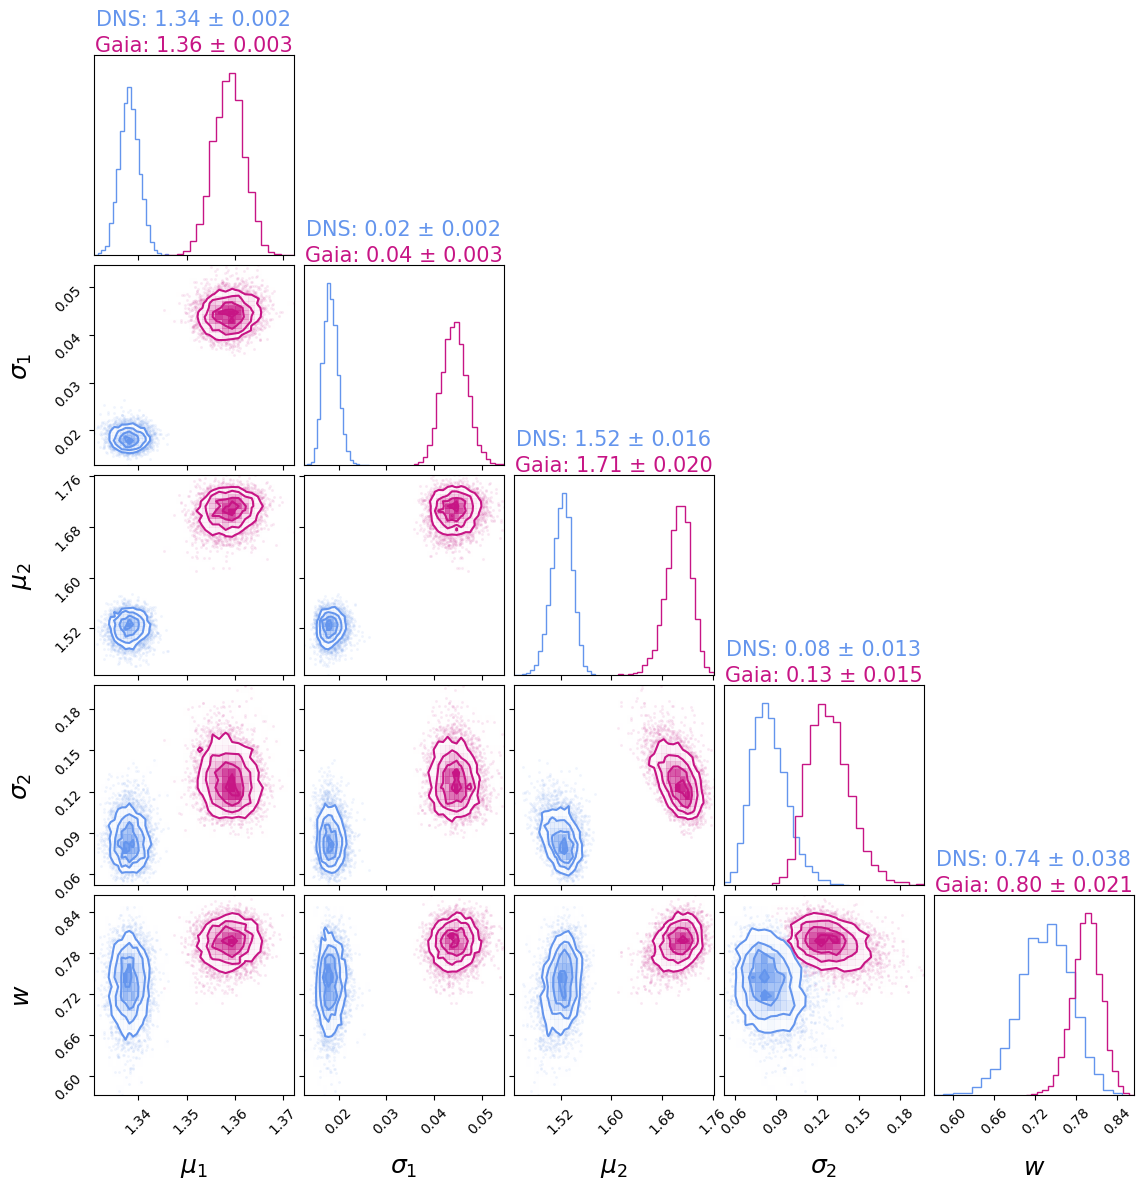

In [ ]:
# Variables
params = ['mu1', 'sigma1', 'mu2', 'sigma2', 'weight']
labels = [r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"]

# Step 1: Plot both datasets without titles
fig = corner.corner(
    DNS_corner_samples,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    gaia_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumvioletred',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

# Step 2: Add your own titles manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_dns = np.median(DNS_corner_samples.posterior[param])
    std_dns = np.std(DNS_corner_samples.posterior[param])
    median_gaia = np.median(gaia_corner_samples.posterior[param])
    std_gaia = np.std(gaia_corner_samples.posterior[param])

    # Add DNS title (top line)
    ax.text(0.5, 1.13,
            f"DNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)

    # Add Gaia title (second line just below)
    ax.text(0.5, 1.00,
            f"Gaia: {median_gaia:.2f} ± {std_gaia:.3f}",
            fontsize=15, color='mediumvioletred',
            ha='center', va='bottom', transform=ax.transAxes)
plt.show()

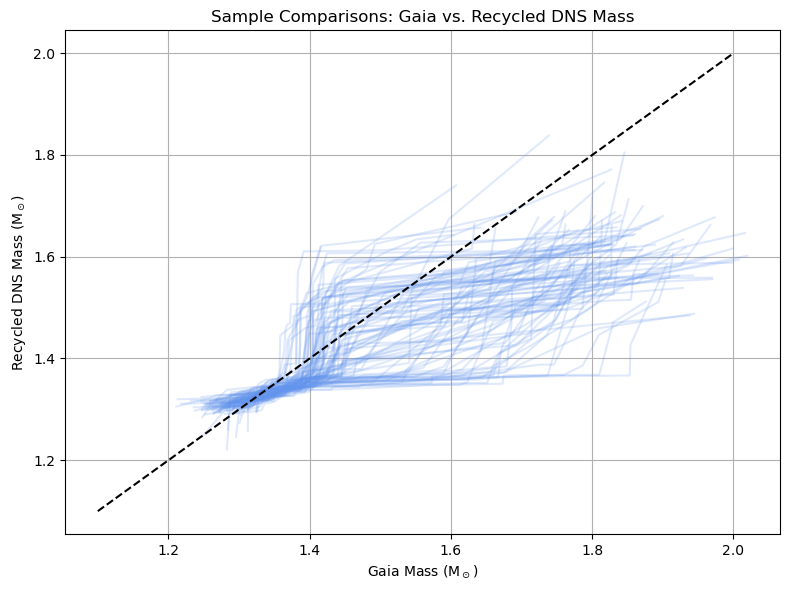

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# Function to sample from a 2-component Gaussian mixture
def sample_from_mixture(mu1, sigma1, mu2, sigma2, weight, size=1):
    components = np.random.rand(size) < weight
    samples = np.where(
        components,
        np.random.normal(mu1, sigma1, size),
        np.random.normal(mu2, sigma2, size)
    )
    return samples

# Prepare plot
plt.figure(figsize=(8, 6))

for _ in range(100):  # Draw and plot 100 sample comparisons
    # Draw 21 samples from Gaia fit
    gaia_idxs = np.random.choice(len(gaiafit_samples['mu1']), 21, replace=False)
    gaia_samples = np.array([
        sample_from_mixture(
            gaiafit_samples['mu1'][i],
            (gaiafit_samples['sigma1'][i]),+
            gaiafit_samples['mu2'][i],
            (gaiafit_samples['sigma2'][i]),
            gaiafit_samples['weight'][i]
        )[0] for i in gaia_idxs
    ])

    # Draw 21 samples from recycled DNS fit
    dns_idxs = np.random.choice(len(recycledDNSfit_samples['mu1']), 21, replace=False)
    dns_samples = np.array([
        sample_from_mixture(
            recycledDNSfit_samples['mu1'][i],
            (recycledDNSfit_samples['sigma1'][i]),
            recycledDNSfit_samples['mu2'][i],
            (recycledDNSfit_samples['sigma2'][i]),
            recycledDNSfit_samples['weight'][i]
        )[0] for i in dns_idxs
    ])

    # Plot sorted pairwise comparison
    plt.plot(np.sort(gaia_samples), np.sort(dns_samples), alpha=0.2, color='cornflowerblue')

# Plot y = x reference line
plt.plot([1.1, 2], [1.1, 2], ls='--', color='k', alpha=1)

plt.xlabel("Gaia Mass (M$_\odot$)")
plt.ylabel("Recycled DNS Mass (M$_\odot$)")
plt.grid(True)
plt.title("Sample Comparisons: Gaia vs. Recycled DNS Mass")
plt.tight_layout()
plt.show()


Percentage Max Gaia samples are bigger than DNS samples: 0.97


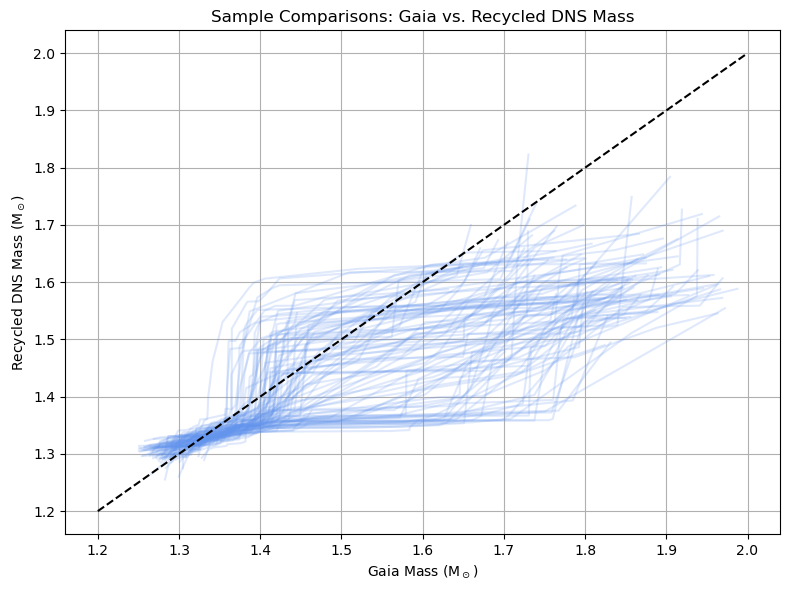

In [ ]:
from scipy.stats import truncnorm
import numpy as np
import matplotlib.pyplot as plt

# Function to sample from a truncated normal distribution
def truncated_normal(mean, std, lower, upper, size=1):
    """
    Generate samples from a truncated normal distribution.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size)

# Function to sample from a 2-component truncated Gaussian mixture
def sample_from_mixture_truncated(mu1, sigma1, mu2, sigma2, weight, lower, upper, size=1):
    """
    Generate samples from a two-component Gaussian mixture with truncation.
    """
    components = np.random.rand(size) < weight
    samples = np.where(
        components,
        truncated_normal(mu1, sigma1, lower, upper, size),
        truncated_normal(mu2, sigma2, lower, upper, size)
    )
    return samples

# Prepare plot
plt.figure(figsize=(8, 6))

lower, upper = 1.25, 2.0  # Truncation bounds

N_gaia_bigger = 0
for _ in range(100):  # Draw and plot 1000 sample comparisons
    # Draw 21 samples from Gaia fit
    gaia_idxs = np.random.choice(len(gaiafit_samples['mu1']), 21, replace=False)
    gaia_samples = np.array([
        sample_from_mixture_truncated(
            gaiafit_samples['mu1'][i],
            (gaiafit_samples['sigma1'][i]),
            gaiafit_samples['mu2'][i],
            (gaiafit_samples['sigma2'][i]),
            gaiafit_samples['weight'][i],
            lower, upper
        )[0] for i in gaia_idxs
    ])

    # Draw 21 samples from recycled DNS fit
    dns_idxs = np.random.choice(len(recycledDNSfit_samples['mu1']), 21, replace=False)
    dns_samples = np.array([
        sample_from_mixture_truncated(
            recycledDNSfit_samples['mu1'][i],
            (recycledDNSfit_samples['sigma1'][i]),
            recycledDNSfit_samples['mu2'][i],
           (recycledDNSfit_samples['sigma2'][i]),
            recycledDNSfit_samples['weight'][i],
            lower, upper
        )[0] for i in dns_idxs
    ])

    # Plot sorted pairwise comparison
    plt.plot(np.sort(gaia_samples), np.sort(dns_samples), alpha=0.2, color='cornflowerblue')
    if max(gaia_samples) > max(dns_samples):
        N_gaia_bigger += 1
print("Percentage Max Gaia samples are bigger than DNS samples:", N_gaia_bigger/100)

# Plot y = x reference line
plt.plot([1.2, 2], [1.2, 2], ls='--', color='k', alpha=1)

plt.xlabel("Gaia Mass (M$_\\odot$)")
plt.ylabel("Recycled DNS Mass (M$_\\odot$)")
plt.grid(True)
plt.title("Sample Comparisons: Gaia vs. Recycled DNS Mass")
plt.tight_layout()
plt.show()